In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [2]:
def read_power_folder_raw(
    folder_path: str,
    date_col: str = "数据日期",
    time_col: str = "时间",
    power_col: str = "功率(KW)",
    keep_source: bool = True
) -> pd.DataFrame:
    """
    仅负责读取 + Time 构造 + 字段规范
    不做任何清洗、补点、插值、修正
    """

    dfs = []

    for file in Path(folder_path).glob("*.xlsx"):
        df = pd.read_excel(file)

        # ========= 1. 构造 Time =========
        time_series = pd.to_datetime(
            df[date_col].astype(str) + " " + df[time_col].astype(str),
            errors="coerce"
        )

        out = pd.DataFrame({
            "Time": time_series,
            "P_kw": df[power_col]
        })
        out["P_kw"] = pd.to_numeric(out["P_kw"], errors="coerce")

        if keep_source:
            out["source_file"] = file.name

        # 只做最基础的合法性过滤
        out = out.dropna(subset=["Time"])

        dfs.append(out)

    if not dfs:
        raise ValueError(f"目录 {folder_path} 下未找到可读取的 Excel 文件")

    df_all = (
        pd.concat(dfs, ignore_index=True)
          .sort_values("Time")
          .reset_index(drop=True)
    )

    return df_all


In [4]:
df_raw = read_power_folder_raw(
    folder_path=r"D:\测算工作\负荷曲线"
)
df_raw = df_raw.drop(columns=["source_file"])
df_raw = df_raw.sort_values("Time")
# print(df_raw.head())

C:\Users\18333\AppData\Local\Temp\ipykernel_18092\2239478245.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  time_series = pd.to_datetime(
C:\Users\18333\AppData\Local\Temp\ipykernel_18092\2239478245.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  time_series = pd.to_datetime(
C:\Users\18333\AppData\Local\Temp\ipykernel_18092\2239478245.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  time_series = pd.to_datetime(
C:\Users\18333\AppData\Local\Temp\ipykernel_18092\2239478245.py:19: UserWarning: Could not infer format, so each element will be parsed individually

In [6]:

month_energy_2025 = {"1月": 49603488, "2月": 45597288, "3月": 58249488, "4月": 56562529 , "5月": 61035744 , "6月": 62137944 , "7月": 66238920, "8月": 63494376, "9月": 53279952, "10月": 57649944 , "11月": 54806928 , "12月": 56779800 }

In [7]:
from calendar import monthrange

def build_daily_energy_2025(month_energy_2025):
    daily_energy = {}
    for m_str, E_month in month_energy_2025.items():
        m = int(m_str.replace("月", ""))
        days = monthrange(2025, m)[1]
        for d in range(1, days + 1):
            daily_energy[pd.Timestamp(2025, m, d).date()] = E_month / days
    return daily_energy
def fill_2025_power_by_daily_energy(df, daily_energy, freq="15T"):
    df = df.copy()
    dt_hours = pd.to_timedelta(freq).total_seconds() / 3600

    df["date"] = df["Time"].dt.date
    df["year"] = df["Time"].dt.year

    for date, E_day in daily_energy.items():

        mask_day = (df["date"] == date) & (df["year"] == 2025)
        day_df = df.loc[mask_day]

        if day_df.empty:
            continue

        # ===== 使用 Time 仅用于插值 =====
        day_df_t = day_df.set_index("Time")

        known_mask = day_df_t["P_kw"].notna()
        missing_mask = day_df_t["P_kw"].isna()

        E_known = (day_df_t.loc[known_mask, "P_kw"] * dt_hours).sum()
        E_missing = E_day - E_known

        if E_missing <= 0 or missing_mask.sum() == 0:
            df.loc[day_df.index[missing_mask.values], "P_kw"] = 0.0
            continue

        weight = (
            day_df_t["P_kw"]
            .interpolate(method="time")
            .fillna(method="bfill")
            .fillna(method="ffill")
            .clip(lower=0)
        )

        # ===== 关键修复：只用 numpy 位置索引 =====
        mask_arr = missing_mask.values
        w = weight.values[mask_arr]

        if w.sum() <= 0:
            w = np.ones_like(w)

        P_fill = w / w.sum() * (E_missing / dt_hours)

        df.loc[
            day_df.index[mask_arr],
            "P_kw"
        ] = P_fill

    return df.drop(columns=["date", "year"])

def smooth_2024_shape(df):
    df = df.copy()

    mask_2024 = (df["Time"].dt.year == 2024) & (df["Time"].dt.month >= 9)
    df_2024 = df.loc[mask_2024]

    if df_2024.empty:
        return df
    s = (
        df_2024
        .set_index("Time")["P_kw"]
        .interpolate(method="time")
        .rolling(3, center=True, min_periods=1)
        .mean()
    )

    # 用位置回写，彻底避免索引对齐问题
    df.loc[df_2024.index, "P_kw"] = s.values

    return df

def shift_2024_to_2025(df):
    df_2024 = df[
        (df["Time"].dt.year == 2024) &
        (df["Time"].dt.month >= 9)
    ].copy()

    df_2024["Time"] = df_2024["Time"] + pd.DateOffset(years=1)
    return df_2024


In [8]:
# 1. 构建 2025 日电量
daily_energy_2025 = build_daily_energy_2025(month_energy_2025)

# 2. 补全 2025 年功率（强约束）
df_step1 = fill_2025_power_by_daily_energy(df_raw, daily_energy_2025)

# 3. 修复 2024 年形态（弱约束）
df_step2 = smooth_2024_shape(df_step1)

# 4. 平移 2024 → 2025
df_shifted = shift_2024_to_2025(df_step2)

# 5. 合并
df_final = (
    pd.concat([df_step2, df_shifted])
    .sort_values("Time")
    .reset_index(drop=True)
)


C:\Users\18333\AppData\Local\Temp\ipykernel_18092\3222747921.py:13: FutureWarning: 'T' is deprecated and will be removed in a future version. Please use 'min' instead of 'T'.
  dt_hours = pd.to_timedelta(freq).total_seconds() / 3600
C:\Users\18333\AppData\Local\Temp\ipykernel_18092\3222747921.py:42: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method="bfill")
C:\Users\18333\AppData\Local\Temp\ipykernel_18092\3222747921.py:43: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method="ffill")
C:\Users\18333\AppData\Local\Temp\ipykernel_18092\3222747921.py:42: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method="bfill")
C:\Users\18333\AppData\Local\Temp\ipykernel_18092\3222747921.py:43: FutureWarning: Ser

In [9]:
def fill_missing_days_by_nearest(df_2025, missing_days, freq="15T"):
    df = df_2025.copy()

    for day in missing_days:
        # 取最近的已有日期（这里明确用 9/3）
        ref_day = min(
            df["Time"].dt.date.unique(),
            key=lambda d: abs(pd.Timestamp(d) - pd.Timestamp(day))
        )

        day_curve = df[df["Time"].dt.date == ref_day].copy()

        # 平移日期
        day_curve["Time"] = day_curve["Time"].apply(
            lambda t: t.replace(year=day.year, month=day.month, day=day.day)
        )

        df = pd.concat([df, day_curve], ignore_index=True)

    return df.sort_values("Time").reset_index(drop=True)


In [10]:
df_2025 = df_final[df_final["Time"].dt.year == 2025].copy()
df_2025 = df_2025.sort_values("Time").reset_index(drop=True)

all_days_2025 = pd.date_range(
    start="2025-01-01",
    end="2025-12-31",
    freq="D"
).date
exist_days_2025 = df_2025["Time"].dt.date.unique()
missing_days_2025 = sorted(set(all_days_2025) - set(exist_days_2025))
df_2025 = fill_missing_days_by_nearest(df_2025, missing_days_2025)

### 光伏出力模拟

In [17]:
import pandas as pd
import pvlib
from pvlib.location import Location


def simulate_pv_output(
    time_index,
    lat: float,
    lon: float,
    capacity_kwp: float = 1.0,
    tilt: float | None = None,
    azimuth: float = 180.0,
    system_loss: float = 0.20,     # ← 提高系统损失
    temp_coeff: float = -0.004,
    cloud_factor: float = 0.75,    # ← 新增云量折减
) -> pd.Series:

    # 时间标准化
    time_index = pd.to_datetime(time_index)
    if not isinstance(time_index, pd.DatetimeIndex):
        time_index = pd.DatetimeIndex(time_index)
    if time_index.tz is None:
        time_index = time_index.tz_localize("Asia/Shanghai")

    if tilt is None:
        tilt = abs(lat)

    location = Location(lat, lon, tz="Asia/Shanghai")

    solpos = location.get_solarposition(time_index)
    clearsky = location.get_clearsky(time_index, model="ineichen")

    poa = pvlib.irradiance.get_total_irradiance(
        surface_tilt=tilt,
        surface_azimuth=azimuth,
        solar_zenith=solpos["zenith"],
        solar_azimuth=solpos["azimuth"],
        dni=clearsky["dni"],
        ghi=clearsky["ghi"],
        dhi=clearsky["dhi"],
    )

    poa_global = poa["poa_global"].clip(lower=0) * cloud_factor

    temp_cell = pvlib.temperature.pvsyst_cell(
        poa_global, temp_air=30, wind_speed=1
    )

    dc = pvlib.pvsystem.pvwatts_dc(
        poa_global, temp_cell, pdc0=1000, gamma_pdc=temp_coeff
    )

    ac = pvlib.inverter.pvwatts(dc, pdc0=1000)
    ac = ac * (1 - system_loss)

    pv_kw = (ac / 1000) * capacity_kwp
    return pv_kw.clip(lower=0, upper=capacity_kwp).rename("pv_kw").tz_localize(None)



In [18]:
def validate_equivalent_hours(pv_kw: pd.Series, capacity_kwp: float):
    dt_h = (pv_kw.index[1] - pv_kw.index[0]).total_seconds() / 3600
    annual_kwh = (pv_kw * dt_h).sum()
    eq_hours = annual_kwh / capacity_kwp
    return eq_hours


In [19]:
import matplotlib.pyplot as plt

def plot_daily_pv_shape(pv_kw, date):
    mask = pv_kw.index.date == pd.to_datetime(date).date()
    plt.figure(figsize=(8, 4))
    plt.plot(pv_kw.loc[mask])
    plt.title(f"PV output on {date}")
    plt.ylabel("kW")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [41]:
pv_kw = simulate_pv_output(
    time_index=df_2025["Time"],
    lat=40.55,
    lon=113.4,
    capacity_kwp=100.0,   # 单位 kWp(MW?)
)

In [42]:
eq_h = validate_equivalent_hours(pv_kw, capacity_kwp=100.0)
print("等效小时:", round(eq_h, 1))

等效小时: 1430.4


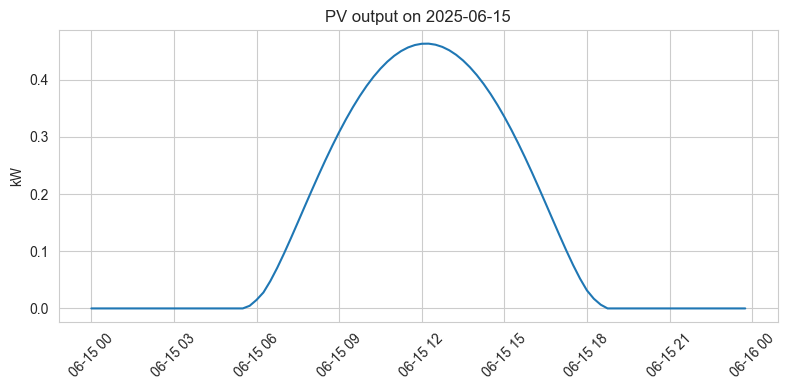

In [16]:
plot_daily_pv_shape(pv_kw, "2025-06-15")

In [17]:
import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import Dict, Optional, Tuple

# ==============================
# 可选：Numba 加速
# ==============================
try:
    from numba import njit
    NUMBA_OK = True
except Exception:
    NUMBA_OK = False
    def njit(*args, **kwargs):
        def deco(f):
            return f
        return deco


# ==============================
# 配置类（默认值 + 可被调用覆盖）
# ==============================
@dataclass
class PlanConfigFast:
    # ---- 成本 ----
    pv_capex_yuan_per_kwp: float = 2000.0
    bess_capex_yuan_per_kwh: float = 1000.0

    # ---- 储能参数 ----
    eta_roundtrip: float = 0.92
    c_rate: float = 0.5
    soc_init_frac: float = 0.5
    soc_min_frac: float = 0.0
    soc_max_frac: float = 1.0

    # ---- 约束比例（默认值）----
    self_use_ratio_min: float = 0.60     # PV_used / PV_gen
    load_cover_ratio_min: float = 0.35   # PV_used / Load

    # ---- 约束口径 ----
    constraint_mode: str = "annual"      # "annual" or "monthly"

    # ---- PV 搜索参数（粗+细）----
    pv_step_coarse_kwp: float = 2000.0
    pv_step_fine_kwp: float = 250.0
    pv_refine_window_kwp: float = 8000.0
    pv_max_kwp: Optional[float] = None

    # ---- 电池搜索 ----
    batt_hi_init_kwh: float = 500.0
    batt_hi_max_kwh: float = 1e7
    batt_bisect_iter: int = 26
    batt_cache_round_kwh: float = 1.0

    # ---- 性能 ----
    use_numba: bool = True


# ==============================
# 基础工具
# ==============================
def _infer_dt_hours(time_col: pd.Series) -> float:
    t = pd.to_datetime(time_col).sort_values()
    dt = t.diff().dropna().mode().iloc[0]
    return dt.total_seconds() / 3600.0


def _align_unit_curve(df_time: pd.Series, pv_unit_kw: pd.Series) -> np.ndarray:
    idx = pd.DatetimeIndex(pd.to_datetime(df_time))
    s = pv_unit_kw.copy()
    s.index = pd.to_datetime(s.index)

    if len(s) == len(idx) and (s.index.values == idx.values).all():
        out = s.to_numpy(dtype="float64")
    else:
        out = s.reindex(idx).interpolate("time").fillna(0.0).to_numpy(dtype="float64")

    return np.ascontiguousarray(out, dtype=np.float64)


def _unit_monthly_kwh(df_time: pd.Series, unit_kw: np.ndarray, dt_hours: float) -> pd.Series:
    tmp = pd.DataFrame({"Time": pd.to_datetime(df_time), "u": unit_kw})
    tmp["m"] = tmp["Time"].dt.to_period("M")
    return tmp.groupby("m")["u"].sum() * dt_hours


# ==============================
# 年度调度（Numba）
# ==============================
@njit
def _dispatch_annual_numba(
    load_kw, pv_kw, dt_hours, batt_kwh,
    eta_roundtrip, c_rate,
    soc_init_frac, soc_min_frac, soc_max_frac
):
    pv_gen = pv_used = load_e = direct_e = bess_dis = 0.0

    if batt_kwh <= 0.0:
        for i in range(load_kw.shape[0]):
            L = max(load_kw[i], 0.0)
            PV = max(pv_kw[i], 0.0)
            load_e += L * dt_hours
            pv_gen += PV * dt_hours
            d = PV if PV < L else L
            pv_used += d * dt_hours
            direct_e += d * dt_hours
        return pv_gen, pv_used, load_e, direct_e, bess_dis

    eta_c = eta_roundtrip ** 0.5
    eta_d = eta_roundtrip ** 0.5
    E = batt_kwh
    Pmax = c_rate * E

    soc_min = soc_min_frac * E
    soc_max = soc_max_frac * E
    soc = soc_init_frac * E
    if soc < soc_min: soc = soc_min
    if soc > soc_max: soc = soc_max

    for i in range(load_kw.shape[0]):
        L = max(load_kw[i], 0.0)
        PV = max(pv_kw[i], 0.0)

        load_e += L * dt_hours
        pv_gen += PV * dt_hours

        direct = PV if PV < L else L
        pv_used += direct * dt_hours
        direct_e += direct * dt_hours

        surplus = PV - direct
        deficit = L - direct

        if surplus > 1e-12 and soc < soc_max:
            charge_p = min(surplus, Pmax, (soc_max - soc) / dt_hours)
            soc += charge_p * dt_hours * eta_c

        if deficit > 1e-12 and soc > soc_min:
            discharge_p = min(deficit, Pmax, (soc - soc_min) * eta_d / dt_hours)
            soc -= discharge_p * dt_hours / eta_d
            pv_used += discharge_p * dt_hours
            bess_dis += discharge_p * dt_hours

    return pv_gen, pv_used, load_e, direct_e, bess_dis


def _dispatch_annual(load_kw, pv_kw, dt_hours, batt_kwh, cfg: PlanConfigFast):
    if cfg.use_numba and NUMBA_OK:
        return dict(zip(
            ["pv_gen_kwh", "pv_used_kwh", "load_kwh", "direct_used_kwh", "bess_discharge_kwh"],
            _dispatch_annual_numba(
                load_kw, pv_kw, dt_hours, batt_kwh,
                cfg.eta_roundtrip, cfg.c_rate,
                cfg.soc_init_frac, cfg.soc_min_frac, cfg.soc_max_frac
            )
        ))

    # Python fallback（省略，性能低，但逻辑一致）
    direct = np.minimum(load_kw, pv_kw)
    return {
        "pv_gen_kwh": float(pv_kw.sum() * dt_hours),
        "pv_used_kwh": float(direct.sum() * dt_hours),
        "load_kwh": float(load_kw.sum() * dt_hours),
        "direct_used_kwh": float(direct.sum() * dt_hours),
        "bess_discharge_kwh": 0.0,
    }


# ==============================
# 主规划函数（完整版）
# ==============================
def plan_pv_bess_min_capex_fast(
    df_2025: pd.DataFrame,
    pv_unit_kw: pd.Series,
    load_col: str = "P_kw",
    time_col: str = "Time",
    cfg: PlanConfigFast = PlanConfigFast(),
    # ===== 关键：比例阈值可在调用时覆盖 =====
    self_use_ratio_min: Optional[float] = None,
    load_cover_ratio_min: Optional[float] = None,
) -> Dict[str, object]:
    """
    输出：
      PV装机容量(kWp)
      PV全年各月发电量(kWh)
      PV投资(元)
      储能装机容量(kWh)
      储能投资(元)
    """

    # ---- 覆盖比例阈值（若调用时传入）----
    if self_use_ratio_min is not None:
        cfg.self_use_ratio_min = float(self_use_ratio_min)
    if load_cover_ratio_min is not None:
        cfg.load_cover_ratio_min = float(load_cover_ratio_min)

    df = df_2025[[time_col, load_col]].copy()
    df[time_col] = pd.to_datetime(df[time_col])
    df = df.sort_values(time_col).reset_index(drop=True)

    dt_hours = _infer_dt_hours(df[time_col])
    load_kw = pd.to_numeric(df[load_col], errors="coerce").fillna(0.0).to_numpy(dtype="float64")
    unit_kw = _align_unit_curve(df[time_col], pv_unit_kw)

    peak_load = float(load_kw.max())
    pv_max_kwp = cfg.pv_max_kwp or max(cfg.pv_step_coarse_kwp, 3.0 * peak_load)

    unit_monthly_kwh = _unit_monthly_kwh(df[time_col], unit_kw, dt_hours)
    load_kwh_total = float(load_kw.sum() * dt_hours)

    best = None

    pv_candidates = np.arange(cfg.pv_step_coarse_kwp, pv_max_kwp + 1e-9, cfg.pv_step_coarse_kwp)

    for pv_kwp in pv_candidates:
        pv_kw = unit_kw * pv_kwp

        # ---- 快速剪枝 ----
        if pv_kw.sum() * dt_hours < cfg.load_cover_ratio_min * load_kwh_total:
            continue

        stats = _dispatch_annual(load_kw, pv_kw, dt_hours, 0.0, cfg)
        if stats["pv_gen_kwh"] <= 0:
            continue

        self_use = stats["pv_used_kwh"] / stats["pv_gen_kwh"]
        cover = stats["pv_used_kwh"] / load_kwh_total

        if self_use < cfg.self_use_ratio_min or cover < cfg.load_cover_ratio_min:
            continue

        pv_capex = pv_kwp * cfg.pv_capex_yuan_per_kwp
        total_capex = pv_capex

        if best is None or total_capex < best["total_capex_yuan"]:
            best = {
                "pv_kwp": float(pv_kwp),
                "pv_monthly_kwh": unit_monthly_kwh * pv_kwp,
                "pv_capex_yuan": pv_capex,
                "bess_kwh": 0.0,
                "bess_capex_yuan": 0.0,
                "total_capex_yuan": total_capex,
                "self_use_ratio": self_use,
                "load_cover_ratio": cover,
                "engine": "numba" if (cfg.use_numba and NUMBA_OK) else "python",
            }

    if best is None:
        raise ValueError("未找到满足约束的 PV+储能配置，请检查比例或扩大搜索范围。")

    return best


In [18]:
cfg = PlanConfigFast(
    constraint_mode="annual",
    pv_step_coarse_kwp=2000.0,
    pv_step_fine_kwp=500.0,
    pv_refine_window_kwp=8000.0,
    pv_max_kwp=None,
    self_use_ratio_min=0.60,
    load_cover_ratio_min=0.35,
)

res = plan_pv_bess_min_capex_fast(
    df_2025=df_2025,
    pv_unit_kw=pv_kw,
    load_col="P_kw",
    time_col="Time",
    cfg=cfg,
)

print("PV装机(kWp):", res["pv_kwp"])
print("PV投资(元):", res["pv_capex_yuan"])
print("储能容量(kWh):", res["bess_kwh"])
print("储能投资(元):", res["bess_capex_yuan"])

print("\nPV各月发电量(kWh):")
print(res["pv_monthly_kwh"])

print("\n约束指标：")
print("口径:", cfg.constraint_mode)
print("PV自用率 PV_used / PV_gen:", res["self_use_ratio"])
print("PV覆盖率 PV_used / Load:", res["load_cover_ratio"])


PV装机(kWp): 244000.0
PV投资(元): 488000000.0
储能容量(kWh): 0.0
储能投资(元): 0.0

PV各月发电量(kWh):
m
2025-01    2.363042e+07
2025-02    2.326015e+07
2025-03    2.732649e+07
2025-04    2.701357e+07
2025-05    2.702194e+07
2025-06    2.566667e+07
2025-07    2.626290e+07
2025-08    2.645395e+07
2025-09    2.563210e+07
2025-10    2.543890e+07
2025-11    2.290931e+07
2025-12    2.258291e+07
Freq: M, Name: u, dtype: float64

约束指标：
口径: annual
PV自用率 PV_used / PV_gen: 0.8141424804656708
PV覆盖率 PV_used / Load: 0.3505189064662031


In [73]:
res["pv_monthly_kwh"].to_csv("pv_monthly_kwh.csv")

In [19]:
import pandas as pd

def simple_energy_sanity_check(
    df_2025: pd.DataFrame,
    time_col="Time",
    load_col="P_kw",
    target_cover=0.30,
    self_use_min=0.60,
    yield_list=(1000, 1100, 1200, 1300),  # kWh/kWp·年
):
    df = df_2025[[time_col, load_col]].copy()
    df[time_col] = pd.to_datetime(df[time_col])
    df = df.sort_values(time_col)

    dt_h = df[time_col].diff().dropna().mode().iloc[0].total_seconds() / 3600
    load_kwh_year = df[load_col].sum() * dt_h

    pv_used_target = target_cover * load_kwh_year
    pv_gen_required = pv_used_target / self_use_min

    rows = []
    for y in yield_list:
        rows.append({
            "yield_kWh_per_kWp_yr": y,
            "pv_required_MWp": pv_gen_required / y / 1000
        })

    return {
        "load_gwh_year": load_kwh_year / 1e6,
        "pv_used_target_gwh": pv_used_target / 1e6,
        "pv_gen_required_gwh": pv_gen_required / 1e6,
        "pv_required_table": pd.DataFrame(rows)
    }

out_A = simple_energy_sanity_check(df_2025)
print("年用电量(GWh):", out_A["load_gwh_year"])
print(out_A["pv_required_table"])


年用电量(GWh): 704.2342685236559
   yield_kWh_per_kWp_yr  pv_required_MWp
0                  1000       352.117134
1                  1100       320.106486
2                  1200       293.430945
3                  1300       270.859334


In [20]:
def curve_based_energy_check(
    df_2025: pd.DataFrame,
    pv_unit_kw: pd.Series,
    time_col="Time",
    load_col="P_kw",
    target_cover=0.30,
    self_use_min=0.60,
):
    df = df_2025[[time_col, load_col]].copy()
    df[time_col] = pd.to_datetime(df[time_col])
    df = df.sort_values(time_col)

    pv_unit_kw = pv_unit_kw.reindex(df[time_col]).fillna(0.0)

    dt_h = df[time_col].diff().dropna().mode().iloc[0].total_seconds() / 3600
    load_kwh_year = df[load_col].sum() * dt_h

    # 单位 kWp 年发电量
    yield_curve = pv_unit_kw.sum() * dt_h

    pv_used_target = target_cover * load_kwh_year
    pv_gen_required = pv_used_target / self_use_min
    pv_kwp_required = pv_gen_required / yield_curve

    return {
        "load_gwh_year": load_kwh_year / 1e6,
        "yield_curve_kWh_per_kWp": yield_curve,
        "pv_required_MWp": pv_kwp_required / 1000
    }

out_B = curve_based_energy_check(df_2025, pv_kw)
print(out_B)


{'load_gwh_year': np.float64(704.2342685236559), 'yield_curve_kWh_per_kWp': np.float64(1242.6200594225356), 'pv_required_MWp': np.float64(283.3666908817343)}


In [71]:
comparison = pd.DataFrame([
    {
        "method": "A-年能量下界(1200h)",
        "pv_mwp": out_A["pv_required_table"]
                  .query("yield_kWh_per_kWp_yr==1200")["pv_required_MWp"].iloc[0]
    },
    {
        "method": "B-单位曲线能量",
        "pv_mwp": out_B["pv_required_MWp"]
    },
    {
        "method": "C-规划模型输出",
        "pv_mwp": 244.0
    }
])

print(comparison)


           method      pv_mwp
0  A-年能量下界(1200h)  293.430945
1        B-单位曲线能量  283.366691
2        C-规划模型输出  244.000000


### 风电出力模拟

In [1]:
import requests
from dataclasses import dataclass
from typing import Optional, Dict
from calendar import monthrange
from windpowerlib import WindTurbine, ModelChain

In [7]:
import pandas as pd
import numpy as np

In [4]:
def fetch_era5_land_open_meteo(
    lat: float,
    lon: float,
    start_date: str,   # YYYY-MM-DD
    end_date: str,     # YYYY-MM-DD
) -> pd.DataFrame:
    """
    通过 Open-Meteo 获取 ERA5-Land 小时级气象
    返回列：Time, wind_speed_100m, temperature_2m
    """
    url = "https://archive-api.open-meteo.com/v1/era5"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": ["wind_speed_100m", "temperature_2m"],
        "timezone": "UTC",
    }

    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    data = r.json()["hourly"]

    df = pd.DataFrame({
        "Time": pd.to_datetime(data["time"]),
        "wind_speed_100m": data["wind_speed_100m"],
        "temperature_2m": data["temperature_2m"],
    })

    return df.sort_values("Time").reset_index(drop=True)


In [12]:
def resample_hourly_to_15min(df_hourly: pd.DataFrame) -> pd.DataFrame:
    df = df_hourly.copy()
    df["Time"] = pd.to_datetime(df["Time"])
    df = df.set_index("Time").sort_index()

    full_index = pd.date_range(df.index.min(), df.index.max(), freq="15min")

    df = (
        df.reindex(full_index)
        .interpolate("time")
        .ffill()
        .bfill()
    )

    df.index.name = "Time"
    return df.reset_index()


In [8]:
def calibrate_energy_with_cap(
    p_base_mw: np.ndarray,
    cap_mw: float,
    dt_h: float,
    target_flh: float,
    tol_flh: float = 0.2,
    max_iter: int = 60,
) -> np.ndarray:
    """
    在 clip(0, cap_mw) 约束下，通过二分法寻找缩放系数，
    使等效利用小时逼近 target_flh。
    """
    target_energy = cap_mw * target_flh

    def energy(scale: float) -> float:
        return float(np.clip(p_base_mw * scale, 0.0, cap_mw).sum() * dt_h)

    # 边界情况
    if energy(1.0) <= 1e-12:
        return np.zeros_like(p_base_mw)

    lo, hi = 0.0, 1.0
    while energy(hi) < target_energy and hi < 1e6:
        hi *= 2.0

    # 如果无论如何都达不到（理论上极少见）
    if energy(hi) < target_energy:
        return np.clip(p_base_mw * hi, 0.0, cap_mw)

    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        e_mid = energy(mid)
        flh_mid = e_mid / cap_mw

        if abs(flh_mid - target_flh) <= tol_flh:
            return np.clip(p_base_mw * mid, 0.0, cap_mw)

        if e_mid < target_energy:
            lo = mid
        else:
            hi = mid

    return np.clip(p_base_mw * 0.5 * (lo + hi), 0.0, cap_mw)


In [9]:
from dataclasses import dataclass

@dataclass
class WindFarmConfig:
    farm_capacity_mw: float = 50.0

    # 校正目标
    mean_wind_speed_140m: float = 5.5
    eq_full_load_hours: float = 1902.7

    # 高度与地形
    meteo_height_m: float = 100.0
    met_mast_height_m: float = 140.0
    hub_height_m: float = 100.0
    shear_alpha: float = 0.20

    # 时间
    year: int = 2025
    freq: str = "15T"

    # 风机（≤8MW，低风速）
    rated_power_kw: float = 8000.0
    cut_in: float = 3.0
    rated_speed: float = 11.0
    cut_out: float = 25.0


In [22]:
import copy

In [43]:
import numpy as np
import pandas as pd
from dataclasses import dataclass
from windpowerlib import WindTurbine, ModelChain


# ============================================================
# 配置
# ============================================================

@dataclass
class WindFarmConfig:
    year: int = 2025
    # freq: str = "15min"
    freq: str = "1h"

    farm_capacity_mw: float = 80.0
    hub_height_m: float = 140.0

    rated_power_kw: float = 5000.0
    cut_in: float = 3.0
    rated_speed: float = 11.0
    cut_out: float = 25.0

    meteo_height_m: float = 100.0
    met_mast_height_m: float = 140.0
    shear_alpha: float = 0.2

    mean_wind_speed_140m: float = 5.5
    eq_full_load_hours: float = 1900.0
    flh_tol: float = 0.3

    max_power_ratio: float = 1.2   # 峰值 ≤ 1.2 × 装机


# ============================================================
# 主模型
# ============================================================

class WindFarmPowerModelERA5Land:

    def __init__(self, cfg: WindFarmConfig):
        self.cfg = cfg
        self.dt_h = pd.to_timedelta(cfg.freq).total_seconds() / 3600.0

    # -----------------------------
    # 幂律
    # -----------------------------
    @staticmethod
    def power_law(v, h_from, h_to, alpha):
        return v * (h_to / h_from) ** alpha

    # -----------------------------
    # 风机
    # -----------------------------
    def build_turbine(self) -> WindTurbine:
        v = np.arange(0, 31, 0.5)
        p = np.zeros_like(v)

        m1 = (v >= self.cfg.cut_in) & (v < self.cfg.rated_speed)
        p[m1] = (
            ((v[m1] - self.cfg.cut_in)
             / (self.cfg.rated_speed - self.cfg.cut_in)) ** 3
            * self.cfg.rated_power_kw
        )

        m2 = (v >= self.cfg.rated_speed) & (v < self.cfg.cut_out)
        p[m2] = self.cfg.rated_power_kw

        return WindTurbine(
            hub_height=self.cfg.hub_height_m,
            nominal_power=self.cfg.rated_power_kw,
            power_curve=pd.DataFrame(
                {"wind_speed": v, "value": p}
            ),
        )

    # ========================================================
    # 🔑 关键函数：带峰值约束的迭代能量回补
    # ========================================================
    @staticmethod
    def _rescale_with_cap_iterative(
        p_base_mw: np.ndarray,
        cap_mw: float,
        dt_h: float,
        target_flh: float,
        max_ratio: float,
        tol_flh: float,
        max_iter: int = 8,
    ) -> np.ndarray:
        """
        目标：
        1) 峰值 ≤ max_ratio × cap_mw
        2) 年 FLH ≈ target_flh
        3) 能量守恒（削峰后通过未饱和时段回补）
        """

        target_energy = cap_mw * target_flh
        p = p_base_mw.copy()
        max_p = cap_mw * max_ratio

        for _ in range(max_iter):
            # ---- 1. 全局缩放到目标能量 ----
            cur_energy = p.sum() * dt_h
            if cur_energy <= 0:
                break
            p *= target_energy / cur_energy

            # ---- 2. 峰值约束 ----
            p_clipped = np.minimum(p, max_p)

            # ---- 3. 计算当前 FLH ----
            energy = p_clipped.sum() * dt_h
            flh = energy / cap_mw

            if abs(flh - target_flh) <= tol_flh:
                return p_clipped

            # ---- 4. 回补被削掉的能量 ----
            deficit = target_energy - energy
            if deficit <= 0:
                return p_clipped

            margin = max_p - p_clipped
            margin[margin < 0] = 0.0
            if margin.sum() <= 0:
                return p_clipped

            p = p_clipped + margin / margin.sum() * (deficit / dt_h)

        return p_clipped

    # ========================================================
    # 主函数
    # ========================================================
    def simulate(
        self,
        lat: float,
        lon: float,
        output_unit: str = "MW",
    ) -> pd.DataFrame:

        # ========= 1. 气象 =========
        df_hour = fetch_era5_land_open_meteo(
            lat=lat,
            lon=lon,
            start_date=f"{self.cfg.year}-01-01",
            end_date=f"{self.cfg.year}-12-31",
        )
        # df_15 = resample_hourly_to_15min(df_hour)
        df_15 = copy.deepcopy(df_hour)

        ti = pd.date_range(
            f"{self.cfg.year}-01-01 00:00:00",
            f"{self.cfg.year}-12-31 23:45:00",
            freq=self.cfg.freq,
        )

        df_15 = (
            df_15.set_index("Time")
            .reindex(ti)
            .interpolate("time")
            .ffill()
            .bfill()
        )

        # ========= 2. 风速处理 =========
        ws_100 = df_15["wind_speed_100m"].clip(lower=0)

        ws_140 = self.power_law(
            ws_100,
            self.cfg.meteo_height_m,
            self.cfg.met_mast_height_m,
            self.cfg.shear_alpha,
        )
        ws_140 *= self.cfg.mean_wind_speed_140m / ws_140.mean()

        ws_hub = self.power_law(
            ws_140,
            self.cfg.met_mast_height_m,
            self.cfg.hub_height_m,
            self.cfg.shear_alpha,
        )

        # ========= 3. 单机功率 =========
        weather = pd.DataFrame(
            {
                ("wind_speed", self.cfg.hub_height_m): ws_hub.values,
                ("temperature", 2.0): (df_15["temperature_2m"] + 273.15).values,
            },
            index=ti,
        )

        turbine = self.build_turbine()
        mc = ModelChain(turbine).run_model(weather)
        p_single_kw = mc.power_output.values

        # ========= 4. 风场聚合 =========
        n_turb = max(
            1,
            int(round(self.cfg.farm_capacity_mw * 1000 / turbine.nominal_power)),
        )
        p_base_mw = p_single_kw * n_turb / 1000.0

        # ========= 5. 二次标定（核心） =========
        p_final = self._rescale_with_cap_iterative(
            p_base_mw=p_base_mw,
            cap_mw=self.cfg.farm_capacity_mw,
            dt_h=self.dt_h,
            target_flh=self.cfg.eq_full_load_hours,
            max_ratio=self.cfg.max_power_ratio,
            tol_flh=self.cfg.flh_tol,
        )

        # ========= 6. 输出 =========
        unit = output_unit.upper()
        if unit == "MW":
            return pd.DataFrame(
                {"WindPower_MW": p_final},
                index=ti,
            )
        elif unit == "KW":
            return pd.DataFrame(
                {"WindPower_kW": p_final * 1000.0},
                index=ti,
            )
        else:
            raise ValueError("output_unit must be 'MW' or 'kW'")


In [44]:
cfg_wind = WindFarmConfig(
    farm_capacity_mw=200.0,
    mean_wind_speed_140m=7.27,
    eq_full_load_hours=2590,
)

model = WindFarmPowerModelERA5Land(cfg_wind)

df_wind = model.simulate(
    lat=40.55,
    lon=113.4,
)


In [50]:
df_wind.iloc[:10]

,WindPower_MW,Time
2025-01-01 00:00:00,0.000000,2025-01-01 00:00:00
2025-01-01 01:00:00,0.000000,2025-01-01 01:00:00
2025-01-01 02:00:00,0.000000,2025-01-01 02:00:00
2025-01-01 03:00:00,0.133326,2025-01-01 03:00:00
2025-01-01 04:00:00,0.571669,2025-01-01 04:00:00
2025-01-01 05:00:00,0.000000,2025-01-01 05:00:00
2025-01-01 06:00:00,0.000000,2025-01-01 06:00:00
2025-01-01 07:00:00,0.107199,2025-01-01 07:00:00
2025-01-01 08:00:00,1.850709,2025-01-01 08:00:00
2025-01-01 09:00:00,191.507549,2025-01-01 09:00:00


In [49]:
df_wind["Time"] = df_wind.index

In [38]:
df_wind.to_csv("D:\\228-售前测算\\乌兰察布\\df_wind_2026.csv", encoding="utf-8")

In [46]:
pv_kw_50m = simulate_pv_output(
    time_index=df_2025["Time"],
    lat=40.55,
    lon=113.4,
    capacity_kwp=100000.0,   # 单位 kWp
)

In [40]:
df_2025 = pd.read_csv("D:\\228-售前测算\\乌兰察布\\df_2025.csv", encoding="utf_8_sig")

### 风光固定条件下,储能寻优

In [47]:
import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import Dict, Any, Optional


# =========================
# 配置
# =========================
@dataclass
class BESSRuleConfig:
    freq: str = "1h"
    eta_charge: float = 0.92
    eta_discharge: float = 0.92
    soc_init: float = 0.5
    soc_min: float = 0.0
    soc_max: float = 1.0
    hours_to_full: float = 2.0        # 0.5C => 2h 充满
    switch_gap_hours: float = 1.0     # 充放之间间隔 1 小时


def _ensure_time_sorted(df, time_col: str) -> pd.DataFrame:
    """
    统一处理：
    - Series / DataFrame
    - Time 在列 / Time 在 DatetimeIndex
    返回：一定是 DataFrame，且 Time 在列
    """
    # ---------- 1. Series → DataFrame ----------
    if isinstance(df, pd.Series):
        name = df.name if df.name is not None else "value"
        df = df.to_frame(name)

    df = df.copy()

    # ---------- 2. Time 在 index ----------
    if time_col not in df.columns:
        if isinstance(df.index, pd.DatetimeIndex):
            df = df.reset_index()
        else:
            raise KeyError(
                f"找不到时间列 '{time_col}'，且 index 不是 DatetimeIndex"
            )

    # ---------- 3. 确保 Time 可解析 ----------
    df[time_col] = pd.to_datetime(df[time_col])

    return df.sort_values(time_col)




def align_curves(
    df_load: pd.DataFrame,
    df_pv: pd.DataFrame,
    df_wind: pd.DataFrame,
    load_col: str,
    pv_col: str,
    wind_col: str,
    time_col: str = "Time",
) -> pd.DataFrame:
    """
    输出统一表：Time, load_kw, pv_kw, wind_kw, gen_kw
    wind_col 输入为 MW 时会自动转 kW
    """
    df_load = _ensure_time_sorted(df_load, time_col)
    df_pv = _ensure_time_sorted(df_pv, time_col)
    df_wind = _ensure_time_sorted(df_wind, time_col)

    a = df_load[[time_col, load_col]].rename(columns={load_col: "load_kw"})
    b = df_pv[[time_col, pv_col]].rename(columns={pv_col: "pv_kw"})
    c = df_wind[[time_col, wind_col]].rename(columns={wind_col: "wind_mw"})

    df = a.merge(b, on=time_col, how="outer").merge(c, on=time_col, how="outer")
    df = df.sort_values(time_col).reset_index(drop=True)

    df["load_kw"] = pd.to_numeric(df["load_kw"], errors="coerce").fillna(0.0)
    df["pv_kw"] = pd.to_numeric(df["pv_kw"], errors="coerce").fillna(0.0)
    df["wind_kw"] = pd.to_numeric(df["wind_mw"], errors="coerce").fillna(0.0) * 1000.0
    df = df.drop(columns=["wind_mw"])

    df["gen_kw"] = df["pv_kw"] + df["wind_kw"]
    return df


def energy_gate_check(
    df_mix: pd.DataFrame,
    freq: str = "15T",
    target_ratio: float = 0.30
) -> Dict[str, Any]:
    """
    先判断：发电量(风+光) / 用电量 是否 >= target_ratio
    仅能量层面，不考虑弃电与储能。
    """
    dt_h = pd.to_timedelta(freq).total_seconds() / 3600.0

    load_kwh = float(df_mix["load_kw"].sum() * dt_h)
    gen_kwh = float(df_mix["gen_kw"].sum() * dt_h)
    ratio = 0.0 if load_kwh <= 0 else gen_kwh / load_kwh

    return {
        "load_total_kwh": load_kwh,
        "gen_total_kwh": gen_kwh,
        "gen_ratio": ratio,
        "pass_gate": (ratio >= target_ratio)
    }


def simulate_bess_for_coverage(
    df_mix: pd.DataFrame,
    bess_kwh: float,
    cfg: BESSRuleConfig,
) -> Dict[str, Any]:
    """
    贪心调度：最大化可再生对负荷的供给。
    充电仅来自 surplus=gen-load（弃电候选）。
    放电仅供 deficit=load-gen，且不超过负荷缺口。
    充放切换间隔 switch_gap_hours。
    0.5C: Pmax = E/hours_to_full
    """
    df = df_mix.copy()
    dt_h = pd.to_timedelta(cfg.freq).total_seconds() / 3600.0
    gap_steps = int(round(cfg.switch_gap_hours / dt_h))

    cap_kwh = float(max(bess_kwh, 0.0))
    pmax_kw = 0.0 if cap_kwh <= 0 else cap_kwh / cfg.hours_to_full

    e = cap_kwh * cfg.soc_init
    e_min = cap_kwh * cfg.soc_min
    e_max = cap_kwh * cfg.soc_max

    last_action = 0
    last_action_t = -10**9

    direct_used_kwh = 0.0
    discharge_used_kwh = 0.0
    curtailed_kwh = 0.0

    load_total_kwh = float(df["load_kw"].sum() * dt_h)

    for i in range(len(df)):
        load = float(df.at[i, "load_kw"])
        gen = float(df.at[i, "gen_kw"])

        direct = min(load, gen)
        direct_used_kwh += direct * dt_h

        surplus = max(gen - load, 0.0)
        deficit = max(load - gen, 0.0)

        can_charge = not (last_action == -1 and (i - last_action_t) < gap_steps)
        can_discharge = not (last_action == +1 and (i - last_action_t) < gap_steps)

        # charge
        p_ch = 0.0
        if surplus > 0 and cap_kwh > 0 and can_charge:
            p_ch_cap = (e_max - e) / max(dt_h * cfg.eta_charge, 1e-9)
            p_ch = min(surplus, pmax_kw, p_ch_cap)
            if p_ch > 1e-9:
                e += p_ch * dt_h * cfg.eta_charge
                last_action, last_action_t = +1, i

        # discharge
        p_dis = 0.0
        if deficit > 0 and cap_kwh > 0 and can_discharge:
            p_dis_cap = (e - e_min) * cfg.eta_discharge / max(dt_h, 1e-9)
            p_dis = min(deficit, pmax_kw, p_dis_cap)
            if p_dis > 1e-9:
                e -= (p_dis * dt_h) / cfg.eta_discharge
                discharge_used_kwh += p_dis * dt_h
                last_action, last_action_t = -1, i

        curtailed = max(surplus - p_ch, 0.0)
        curtailed_kwh += curtailed * dt_h

    renewable_used_kwh = direct_used_kwh + discharge_used_kwh
    cover_ratio = 0.0 if load_total_kwh <= 0 else renewable_used_kwh / load_total_kwh

    return {
        "bess_kwh": cap_kwh,
        "pmax_kw": pmax_kw,
        "load_total_kwh": load_total_kwh,
        "direct_used_kwh": direct_used_kwh,
        "discharge_used_kwh": discharge_used_kwh,
        "renewable_used_kwh": renewable_used_kwh,
        "cover_ratio": cover_ratio,
        "curtailed_kwh": curtailed_kwh,
    }


def estimate_min_bess_capacity(
    df_mix: pd.DataFrame,
    cfg: BESSRuleConfig,
    target_cover_ratio: float = 0.30,
    cap_high_kwh: Optional[float] = None,
    max_iter: int = 28,
) -> Dict[str, Any]:
    """
    二分搜索最小 BESS 容量，使 cover_ratio >= target_cover_ratio
    """
    baseline = simulate_bess_for_coverage(df_mix, 0.0, cfg)
    if baseline["cover_ratio"] >= target_cover_ratio:
        return {"status": "no_bess_needed", "baseline": baseline, "best": baseline}

    if cap_high_kwh is None:
        surplus_kw = np.maximum(df_mix["gen_kw"].values - df_mix["load_kw"].values, 0.0)
        cap_high_kwh = max(1_000.0, float(np.max(surplus_kw)) * 6.0)

    lo, hi = 0.0, float(cap_high_kwh)

    # 扩边界直到可行
    res_hi = simulate_bess_for_coverage(df_mix, hi, cfg)
    expand = 0
    while res_hi["cover_ratio"] < target_cover_ratio and expand < 12:
        hi *= 2.0
        res_hi = simulate_bess_for_coverage(df_mix, hi, cfg)
        expand += 1

    if res_hi["cover_ratio"] < target_cover_ratio:
        return {"status": "not_reachable", "baseline": baseline, "try_hi": res_hi}

    best = res_hi
    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        res_mid = simulate_bess_for_coverage(df_mix, mid, cfg)

        if res_mid["cover_ratio"] >= target_cover_ratio:
            best = res_mid
            hi = mid
        else:
            lo = mid

        if (hi - lo) / max(hi, 1.0) < 0.01:
            break

    return {"status": "ok", "baseline": baseline, "best": best}


def evaluate_50wind_50pv_with_bess(
    df_2025: pd.DataFrame,
    pv_kw_50m: pd.DataFrame,
    df_wind: pd.DataFrame,
    load_col: str = "P_kw",
    pv_col: str = "pv_kw",
    wind_col: str = "WindPower_MW",
    time_col: str = "Time",
    target_ratio: float = 0.30,
    cfg: Optional[BESSRuleConfig] = None
) -> Dict[str, Any]:
    """
    先能量门槛：gen/load >= 30% 才做储能评估
    """
    if cfg is None:
        cfg = BESSRuleConfig()

    df_mix = align_curves(
        df_load=df_2025,
        df_pv=pv_kw_50m,
        df_wind=df_wind,
        load_col=load_col,
        pv_col=pv_col,
        wind_col=wind_col,
        time_col=time_col,
    )

    gate = energy_gate_check(df_mix, freq=cfg.freq, target_ratio=target_ratio)

    out = {
        "df_mix": df_mix,
        "gate": gate,
        "status": "gate_failed" if not gate["pass_gate"] else "gate_passed"
    }

    # 门槛不过：不评估储能
    if not gate["pass_gate"]:
        out["message"] = (
            f"能量门槛未通过：风+光年发电量占比={gate['gen_ratio']:.3f}，"
            f"低于目标{target_ratio:.2f}。在只允许用风光充电的前提下，储能无法把覆盖率提高到30%。"
        )
        return out

    # 门槛通过：再做储能评估（以实现“实际覆盖率>=30%”）
    bess_res = estimate_min_bess_capacity(
        df_mix=df_mix,
        cfg=cfg,
        target_cover_ratio=target_ratio,
    )
    out["bess_result"] = bess_res
    return out


In [51]:
cfg = BESSRuleConfig(
    freq="1h",
    eta_charge=0.92,
    eta_discharge=0.92,
    hours_to_full=2.0,        # 0.5C
    switch_gap_hours=1.0,     # 充放间隔1小时
    soc_init=0.5
)

res = evaluate_50wind_50pv_with_bess(
    df_2025=df_2025,
    pv_kw_50m=pv_kw_50m,
    df_wind=df_wind,
    load_col="P_kw",
    pv_col="pv_kw",
    wind_col="WindPower_MW",
    time_col="Time",
    target_ratio=0.30,
    cfg=cfg
)

print("状态:", res["status"])
print("年负荷(kWh):", res["gate"]["load_total_kwh"])
print("年发电(kWh):", res["gate"]["gen_total_kwh"])
print("发电/负荷比例:", res["gate"]["gen_ratio"])

if res["status"] == "gate_passed":
    br = res["bess_result"]
    print("\n储能评估状态:", br["status"])
    print("无电池覆盖率:", br["baseline"]["cover_ratio"])
    if br["status"] == "ok":
        best = br["best"]
        print("\n满足30%覆盖的最小储能：")
        print("  容量(kWh):", best["bess_kwh"])
        print("  功率上限(kW,0.5C):", best["pmax_kw"])
        print("  覆盖率:", best["cover_ratio"])
        print("  弃电(kWh):", best["curtailed_kwh"])
else:
    print(res["message"])


状态: gate_passed
年负荷(kWh): 1400000000.05
年发电(kWh): 661038973.4338784
发电/负荷比例: 0.47217069529304995

储能评估状态: no_bess_needed
无电池覆盖率: 0.40643771990040667


In [52]:
pv_kw_50m.to_csv("D:\\228-售前测算\\乌兰察布\\pv_kw_100.csv", encoding="utf-8")

In [126]:
print(df_wind.dtypes)
print(df_2025.dtypes)

Time            datetime64[ns]
WindPower_MW           float64
dtype: object
Time    datetime64[ns]
P_kw           float64
dtype: object


In [127]:
df_2025_ = df_2025.copy()
df_2025_["P_kw"] = df_2025_["P_kw"] - df_wind["WindPower_MW"]
print(df_2025_[df_2025_["P_kw"] < 0])
print(df_2025_)


                     Time       P_kw
2527  2025-01-27 07:45:00  -0.508203
4913  2025-02-21 04:15:00  -6.052701
4914  2025-02-21 04:30:00  -5.545550
4915  2025-02-21 04:45:00  -5.135502
5661  2025-02-28 23:15:00  -0.396905
5662  2025-02-28 23:30:00  -0.251360
5663  2025-02-28 23:45:00  -0.172555
6112  2025-03-05 16:00:00 -50.000000
9810  2025-04-13 04:30:00 -26.930228
12236 2025-05-08 11:00:00  -0.007206
15380 2025-06-10 05:00:00  -0.131551
                     Time          P_kw
0     2025-01-01 00:00:00  68596.469278
1     2025-01-01 00:15:00  68608.893591
2     2025-01-01 00:30:00  68618.776593
3     2025-01-01 00:45:00  68626.401256
4     2025-01-01 01:00:00  68631.772693
...                   ...           ...
35035 2025-12-31 22:45:00  67710.000000
35036 2025-12-31 23:00:00  68590.000000
35037 2025-12-31 23:15:00  68590.000000
35038 2025-12-31 23:30:00  68590.000000
35039 2025-12-31 23:45:00  68590.000000

[35040 rows x 2 columns]


In [34]:
from dataclasses import dataclass
from typing import Optional, Dict
import numpy as np
import pandas as pd

try:
    from numba import njit
    NUMBA_OK = True
except Exception:
    NUMBA_OK = False
    def njit(*args, **kwargs):
        def deco(f): return f
        return deco


@dataclass
class PlanConfigFastWind:
    # 成本
    pv_capex_yuan_per_kwp: float = 2000.0
    bess_capex_yuan_per_kwh: float = 1000.0

    # 储能
    eta_roundtrip: float = 0.92
    c_rate: float = 0.5
    soc_init_frac: float = 0.5
    soc_min_frac: float = 0.1
    soc_max_frac: float = 1.0

    # 约束（新能源整体）
    self_use_ratio_min: float = 0.60
    load_cover_ratio_min: float = 0.35

    # PV 搜索
    pv_step_coarse_kwp: float = 2000.0
    pv_step_fine_kwp: float = 250.0
    pv_refine_window_kwp: float = 8000.0
    pv_max_kwp: Optional[float] = None

    # 电池搜索
    batt_hi_init_kwh: float = 1000.0
    batt_hi_max_kwh: float = 1e7
    batt_bisect_iter: int = 24

    use_numba: bool = True


In [35]:
@njit
def _dispatch_annual_fast_numba(
    load_kw, wind_kw, pv_kw, other_kw,
    dt_hours, batt_kwh,
    eta_roundtrip, c_rate,
    soc_init_frac, soc_min_frac, soc_max_frac
):
    gen_e = 0.0
    used_e = 0.0
    load_e = 0.0
    direct_e = 0.0
    bess_dis = 0.0

    eta_c = eta_roundtrip ** 0.5
    eta_d = eta_roundtrip ** 0.5

    E = batt_kwh
    Pmax = c_rate * E

    soc_min = soc_min_frac * E
    soc_max = soc_max_frac * E
    soc = soc_init_frac * E
    if soc < soc_min:
        soc = soc_min
    if soc > soc_max:
        soc = soc_max

    n = load_kw.shape[0]

    for i in range(n):
        # ---- load ----
        L = load_kw[i]
        if L < 0.0:
            L = 0.0

        # ---- generation ----
        G = wind_kw[i] + pv_kw[i] + other_kw[i]
        if G < 0.0:
            G = 0.0

        load_e += L * dt_hours
        gen_e += G * dt_hours

        # ---- direct use ----
        direct = L if L < G else G
        used_e += direct * dt_hours
        direct_e += direct * dt_hours

        surplus = G - direct
        deficit = L - direct

        # ---- charge ----
        if surplus > 1e-9 and soc < soc_max:
            p_ch = surplus
            if p_ch > Pmax:
                p_ch = Pmax
            max_ch = (soc_max - soc) / dt_hours
            if p_ch > max_ch:
                p_ch = max_ch
            soc += p_ch * dt_hours * eta_c

        # ---- discharge ----
        if deficit > 1e-9 and soc > soc_min:
            p_dis = deficit
            if p_dis > Pmax:
                p_dis = Pmax
            max_dis = (soc - soc_min) * eta_d / dt_hours
            if p_dis > max_dis:
                p_dis = max_dis
            soc -= p_dis * dt_hours / eta_d
            used_e += p_dis * dt_hours
            bess_dis += p_dis * dt_hours

    return gen_e, used_e, load_e, direct_e, bess_dis



### wind_fixed_pv_bess_fast

In [36]:
def plan_wind_fixed_pv_bess_fast(
    df_2025: pd.DataFrame,
    pv_unit_kw: pd.Series,        # kW / kWp
    wind_kw: pd.Series,           # kW（50MW 风电）
    load_col: str = "P_kw",
    time_col: str = "Time",
    cfg: PlanConfigFastWind = PlanConfigFastWind(),
) -> Dict[str, object]:

    df = df_2025[[time_col, load_col]].copy()
    df[time_col] = pd.to_datetime(df[time_col])
    df = df.sort_values(time_col).reset_index(drop=True)

    dt_hours = (df[time_col].diff().dropna().mode().iloc[0]).total_seconds() / 3600.0

    load_kw = df[load_col].to_numpy(dtype="float64")
    wind_kw = wind_kw.reindex(df[time_col]).fillna(0.0).to_numpy(dtype="float64")
    unit_kw = pv_unit_kw.reindex(df[time_col]).interpolate("time").fillna(0.0).to_numpy(dtype="float64")

    # 预留：其他新能源
    other_kw = np.zeros_like(load_kw)

    load_kwh_total = load_kw.sum() * dt_hours
    wind_kwh_total = wind_kw.sum() * dt_hours

    peak_load = load_kw.max()
    pv_max_kwp = cfg.pv_max_kwp or max(cfg.pv_step_coarse_kwp, 3.0 * peak_load)

    best = None

    pv_candidates = np.arange(cfg.pv_step_coarse_kwp, pv_max_kwp + 1e-9, cfg.pv_step_coarse_kwp)

    for pv_kwp in pv_candidates:
        pv_kw = unit_kw * pv_kwp
        pv_kwh = pv_kw.sum() * dt_hours

        # ---- 快速能量剪枝 ----
        if wind_kwh_total + pv_kwh < cfg.load_cover_ratio_min * load_kwh_total:
            continue

        # ---- 无电池 ----
        gen_e, used_e, load_e, _, _ = _dispatch_annual_fast_numba(
            load_kw, wind_kw, pv_kw, other_kw,
            dt_hours, 0.0,
            cfg.eta_roundtrip, cfg.c_rate,
            cfg.soc_init_frac, cfg.soc_min_frac, cfg.soc_max_frac
        )

        if gen_e <= 0:
            continue

        self_use = used_e / gen_e
        cover = used_e / load_e

        if self_use < cfg.self_use_ratio_min or cover < cfg.load_cover_ratio_min:
            continue

        # ---- CAPEX ----
        pv_capex = pv_kwp * cfg.pv_capex_yuan_per_kwp

        if best is None or pv_capex < best["total_capex_yuan"]:
            best = {
                "pv_kwp": float(pv_kwp),
                "bess_kwh": 0.0,
                "total_capex_yuan": pv_capex,
                "self_use_ratio": self_use,
                "load_cover_ratio": cover,
                "wind_gen_kwh": wind_kwh_total,
                "pv_gen_kwh": pv_kwh,
            }

    if best is None:
        raise ValueError("未找到满足新能源自用率/覆盖率约束的方案")

    # ---- 月度发电量 ----
    tmp = df.copy()
    tmp["m"] = tmp[time_col].dt.to_period("M")
    pv_monthly = (unit_kw * best["pv_kwp"] * dt_hours)
    wind_monthly = (wind_kw * dt_hours)

    pv_monthly_kwh = tmp.groupby("m").apply(lambda x: pv_monthly[x.index].sum())
    wind_monthly_kwh = tmp.groupby("m").apply(lambda x: wind_monthly[x.index].sum())

    best["pv_monthly_kwh"] = pv_monthly_kwh
    best["wind_monthly_kwh"] = wind_monthly_kwh

    return best


In [117]:
import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import Optional, Dict, Any, Tuple, Union

# ==============================
# 可选：Numba 加速
# ==============================
try:
    from numba import njit
    NUMBA_OK = True
except Exception:
    NUMBA_OK = False
    def njit(*args, **kwargs):
        def deco(f):
            return f
        return deco


# ==============================
# 配置类（可被调用覆盖）
# ==============================
@dataclass
class PlanConfigFastWind:
    # ---- 成本 ----
    pv_capex_yuan_per_kwp: float = 2000.0
    bess_capex_yuan_per_kwh: float = 1000.0

    # ---- 储能参数 ----
    eta_roundtrip: float = 0.92
    c_rate: float = 0.5
    soc_init_frac: float = 0.5
    soc_min_frac: float = 0.0
    soc_max_frac: float = 1.0

    # ---- 约束比例（新能源整体）----
    self_use_ratio_min: float = 0.60     # (Renewable_used) / (Renewable_gen)
    load_cover_ratio_min: float = 0.30   # (Renewable_used) / (Load)

    # ---- PV 搜索参数（粗+细）----
    pv_step_coarse_kwp: float = 2000.0
    pv_step_fine_kwp: float = 250.0
    pv_refine_window_kwp: float = 8000.0
    pv_max_kwp: Optional[float] = None
    pv_min_kwp: float = 0.0

    # ---- 电池搜索（二分）----
    enable_bess: bool = True
    batt_hi_init_kwh: float = 1000.0
    batt_hi_max_kwh: float = 1e7
    batt_bisect_iter: int = 22
    batt_tol_kwh: float = 100.0

    # ---- 性能 ----
    use_numba: bool = True


# ==============================
# 基础工具
# ==============================
def _infer_dt_hours(time_series: pd.Series) -> float:
    t = pd.to_datetime(time_series).sort_values()
    if len(t) < 2:
        raise ValueError("Time 序列长度不足，无法推断 dt")
    dt = t.diff().dropna().mode().iloc[0]
    return dt.total_seconds() / 3600.0


def _as_time_index_series(
    x: Union[pd.Series, pd.DataFrame],
    time_col: str,
    value_col_candidates: Tuple[str, ...],
    *,
    scale: float = 1.0,
) -> pd.Series:
    """
    将输入 x 规范为：Series(index=DatetimeIndex, values=float)
    - x 可为 Series (index为时间) 或 DataFrame(含 time_col + value_col)
    - value_col_candidates 依次尝试
    - scale 用于单位换算（例如 MW->kW）
    """
    if isinstance(x, pd.Series):
        s = x.copy()
        if not isinstance(s.index, pd.DatetimeIndex):
            # 尝试把 index 转成时间
            s.index = pd.to_datetime(s.index)
        s = pd.to_numeric(s, errors="coerce").fillna(0.0) * float(scale)
        return s

    if isinstance(x, pd.DataFrame):
        df = x.copy()
        if time_col not in df.columns:
            # 如果时间在 index
            if isinstance(df.index, pd.DatetimeIndex):
                df = df.reset_index().rename(columns={df.columns[0]: time_col})
            else:
                raise KeyError(f"wind/pv 输入 DataFrame 找不到时间列 {time_col}，且 index 不是 DatetimeIndex")

        df[time_col] = pd.to_datetime(df[time_col])
        vcol = None
        for c in value_col_candidates:
            if c in df.columns:
                vcol = c
                break
        if vcol is None:
            # 兜底：取除 time_col 外第一列
            cand = [c for c in df.columns if c != time_col]
            if not cand:
                raise KeyError(f"输入 DataFrame 除 {time_col} 外无数值列")
            vcol = cand[0]

        s = pd.to_numeric(df[vcol], errors="coerce").fillna(0.0)
        s.index = pd.to_datetime(df[time_col])
        s = s.sort_index() * float(scale)
        return s

    raise TypeError("输入必须是 pd.Series 或 pd.DataFrame")


def _align_to_time(df_time: pd.Series, s: pd.Series) -> np.ndarray:
    """
    对齐到 df_time 的时间轴，返回 1D float64 numpy array
    """
    idx = pd.DatetimeIndex(pd.to_datetime(df_time))
    if isinstance(s.index, pd.DatetimeIndex) and len(s) == len(idx) and (s.index.values == idx.values).all():
        out = s.to_numpy(dtype="float64")
    else:
        out = (
            s.reindex(idx)
             .interpolate("time")
             .fillna(0.0)
             .to_numpy(dtype="float64")
        )
    return np.ascontiguousarray(out, dtype=np.float64)


def _monthly_kwh(df_time: pd.Series, kw_arr: np.ndarray, dt_hours: float) -> pd.Series:
    tmp = pd.DataFrame({"Time": pd.to_datetime(df_time), "kw": kw_arr})
    tmp["m"] = tmp["Time"].dt.to_period("M")
    return (tmp.groupby("m")["kw"].sum() * dt_hours).sort_index()


# ==============================
# 年度调度（Numba / Python）
# ==============================
@njit
def _dispatch_annual_numba(
    load_kw, wind_kw, pv_kw, other_kw,
    dt_hours, batt_kwh,
    eta_roundtrip, c_rate,
    soc_init_frac, soc_min_frac, soc_max_frac
):
    gen_e = 0.0
    used_e = 0.0
    load_e = 0.0
    direct_e = 0.0
    bess_dis = 0.0

    eta_c = eta_roundtrip ** 0.5
    eta_d = eta_roundtrip ** 0.5

    E = batt_kwh
    Pmax = c_rate * E

    soc_min = soc_min_frac * E
    soc_max = soc_max_frac * E
    soc = soc_init_frac * E
    if soc < soc_min:
        soc = soc_min
    if soc > soc_max:
        soc = soc_max

    n = load_kw.shape[0]

    for i in range(n):
        L = load_kw[i]
        if L < 0.0:
            L = 0.0

        G = wind_kw[i] + pv_kw[i] + other_kw[i]
        if G < 0.0:
            G = 0.0

        load_e += L * dt_hours
        gen_e += G * dt_hours

        direct = L if L < G else G
        used_e += direct * dt_hours
        direct_e += direct * dt_hours

        surplus = G - direct
        deficit = L - direct

        # charge
        if surplus > 1e-9 and E > 0.0 and soc < soc_max:
            p_ch = surplus
            if p_ch > Pmax:
                p_ch = Pmax
            max_ch = (soc_max - soc) / dt_hours
            if p_ch > max_ch:
                p_ch = max_ch
            soc += p_ch * dt_hours * eta_c

        # discharge
        if deficit > 1e-9 and E > 0.0 and soc > soc_min:
            p_dis = deficit
            if p_dis > Pmax:
                p_dis = Pmax
            max_dis = (soc - soc_min) * eta_d / dt_hours
            if p_dis > max_dis:
                p_dis = max_dis
            soc -= p_dis * dt_hours / eta_d
            used_e += p_dis * dt_hours
            bess_dis += p_dis * dt_hours

    return gen_e, used_e, load_e, direct_e, bess_dis


def _dispatch_annual(
    load_kw: np.ndarray,
    wind_kw: np.ndarray,
    pv_kw: np.ndarray,
    other_kw: np.ndarray,
    dt_hours: float,
    batt_kwh: float,
    cfg: PlanConfigFastWind
) -> Dict[str, float]:
    if cfg.use_numba and NUMBA_OK:
        gen_e, used_e, load_e, direct_e, bess_dis = _dispatch_annual_numba(
            load_kw, wind_kw, pv_kw, other_kw,
            dt_hours, float(batt_kwh),
            float(cfg.eta_roundtrip), float(cfg.c_rate),
            float(cfg.soc_init_frac), float(cfg.soc_min_frac), float(cfg.soc_max_frac)
        )
    else:
        # Python fallback（矢量化 + 简化电池）
        gen_kw = wind_kw + pv_kw + other_kw
        direct_kw = np.minimum(load_kw, np.maximum(gen_kw, 0.0))
        gen_e = float(np.maximum(gen_kw, 0.0).sum() * dt_hours)
        load_e = float(np.maximum(load_kw, 0.0).sum() * dt_hours)
        used_e = float(direct_kw.sum() * dt_hours)
        direct_e = used_e
        bess_dis = 0.0
        # fallback 不模拟电池，主要用于无 numba 环境的可运行性

    return {
        "ren_gen_kwh": float(gen_e),
        "ren_used_kwh": float(used_e),
        "load_kwh": float(load_e),
        "direct_used_kwh": float(direct_e),
        "bess_discharge_kwh": float(bess_dis),
    }


# ==============================
# 电池二分：给定 PV，找最小 BESS
# ==============================
def _find_min_bess_kwh(
    load_kw: np.ndarray,
    wind_kw: np.ndarray,
    pv_kw: np.ndarray,
    other_kw: np.ndarray,
    dt_hours: float,
    cfg: PlanConfigFastWind
) -> Optional[Tuple[float, Dict[str, float]]]:
    """
    返回 (bess_kwh, stats)；若找不到可行解返回 None
    """
    def feasible(batt_kwh: float) -> Tuple[bool, Dict[str, float]]:
        st = _dispatch_annual(load_kw, wind_kw, pv_kw, other_kw, dt_hours, batt_kwh, cfg)
        gen = st["ren_gen_kwh"]
        used = st["ren_used_kwh"]
        load = st["load_kwh"]
        if gen <= 1e-9:
            return False, st
        self_use = used / gen
        cover = used / load if load > 1e-9 else 0.0
        ok = (self_use >= cfg.self_use_ratio_min) and (cover >= cfg.load_cover_ratio_min)
        st["self_use_ratio"] = self_use
        st["load_cover_ratio"] = cover
        return ok, st

    # 先试 0
    ok0, st0 = feasible(0.0)
    if ok0:
        return 0.0, st0

    # 扩上界
    hi = float(cfg.batt_hi_init_kwh)
    for _ in range(40):
        if hi > cfg.batt_hi_max_kwh:
            return None
        ok, st = feasible(hi)
        if ok:
            break
        hi *= 2.0
    else:
        return None

    lo = 0.0
    best_kwh = hi
    best_st = st

    # 二分
    for _ in range(cfg.batt_bisect_iter):
        mid = 0.5 * (lo + hi)
        ok, st_mid = feasible(mid)
        if ok:
            best_kwh, best_st = mid, st_mid
            hi = mid
        else:
            lo = mid
        if (hi - lo) <= cfg.batt_tol_kwh:
            break

    return float(best_kwh), best_st


# ==============================
# 主规划函数（完整版）
# ==============================
def plan_wind_fixed_pv_bess_fast_full(
    df_2025: pd.DataFrame,
    pv_unit_kw: Union[pd.Series, pd.DataFrame],
    wind_input: Union[pd.Series, pd.DataFrame],
    *,
    load_col: str = "P_kw",
    time_col: str = "Time",
    cfg: PlanConfigFastWind = PlanConfigFastWind(),
    # 预留：其他新能源输入（可空）
    other_input: Optional[Union[pd.Series, pd.DataFrame]] = None,
    other_unit: str = "kW",  # 预留
    # wind 输入单位声明
    wind_unit: str = "MW",   # 你通常是 WindPower_MW
    # pv_unit 是否已经是 kW/kWp（默认是）
) -> Dict[str, Any]:

    # ---- 负荷 ----
    df = df_2025[[time_col, load_col]].copy()
    df[time_col] = pd.to_datetime(df[time_col])
    df = df.sort_values(time_col).reset_index(drop=True)

    dt_hours = _infer_dt_hours(df[time_col])
    load_kw_arr = pd.to_numeric(df[load_col], errors="coerce").fillna(0.0).to_numpy(dtype="float64")
    load_kw_arr = np.ascontiguousarray(load_kw_arr, dtype=np.float64)

    # ---- 风电：支持 DataFrame/Series，自动取 WindPower_MW 或 wind_kw ----
    wind_scale = 1000.0 if wind_unit.lower() == "mw" else 1.0
    wind_s = _as_time_index_series(
        wind_input,
        time_col=time_col,
        value_col_candidates=("WindPower_MW", "wind_mw", "wind_kw", "WindPower_kW", "WindPower"),
        scale=wind_scale,
    )
    wind_kw_arr = _align_to_time(df[time_col], wind_s)

    # ---- PV 单位出力：支持 Series/DataFrame（按 index 或 Time 列）
    pv_unit_s = _as_time_index_series(
        pv_unit_kw,
        time_col=time_col,
        value_col_candidates=("pv_unit_kw", "pv_kw", "u", "value"),
        scale=1.0,
    )
    pv_unit_arr = _align_to_time(df[time_col], pv_unit_s)

    # ---- 其他新能源预留 ----
    if other_input is None:
        other_kw_arr = np.zeros_like(load_kw_arr, dtype=np.float64)
    else:
        other_scale = 1.0 if other_unit.lower() == "kw" else 1000.0
        other_s = _as_time_index_series(
            other_input,
            time_col=time_col,
            value_col_candidates=("other_kw", "OtherPower_kW", "OtherPower"),
            scale=other_scale,
        )
        other_kw_arr = _align_to_time(df[time_col], other_s)

    # ---- 基础量 ----
    load_kwh_total = float(load_kw_arr.sum() * dt_hours)
    wind_kwh_total = float(wind_kw_arr.sum() * dt_hours)

    peak_load = float(load_kw_arr.max()) if len(load_kw_arr) else 0.0
    pv_max_kwp = cfg.pv_max_kwp or max(cfg.pv_step_coarse_kwp, 3.0 * peak_load)

    # 年/月风电发电量输出
    wind_monthly_kwh = _monthly_kwh(df[time_col], wind_kw_arr, dt_hours)

    # ==========================
    # PV 搜索：粗扫 + 可选细扫
    # ==========================
    best = None
    best_pv_kwp_coarse = None

    pv_candidates = np.arange(cfg.pv_min_kwp, pv_max_kwp + 1e-9, cfg.pv_step_coarse_kwp)
    for pv_kwp in pv_candidates:
        pv_kw_arr = pv_unit_arr * float(pv_kwp)
        pv_kwh = float(pv_kw_arr.sum() * dt_hours)

        # --- 快速能量剪枝：风+光至少要到覆盖阈值的“理论上限”
        if (wind_kwh_total + pv_kwh) < cfg.load_cover_ratio_min * load_kwh_total:
            continue

        # --- 可行性判断：无电池或带电池
        if cfg.enable_bess:
            found = _find_min_bess_kwh(load_kw_arr, wind_kw_arr, pv_kw_arr, other_kw_arr, dt_hours, cfg)
            if found is None:
                continue
            bess_kwh, st = found
        else:
            st = _dispatch_annual(load_kw_arr, wind_kw_arr, pv_kw_arr, other_kw_arr, dt_hours, 0.0, cfg)
            if st["ren_gen_kwh"] <= 1e-9:
                continue
            self_use = st["ren_used_kwh"] / st["ren_gen_kwh"]
            cover = st["ren_used_kwh"] / st["load_kwh"]
            if (self_use < cfg.self_use_ratio_min) or (cover < cfg.load_cover_ratio_min):
                continue
            st["self_use_ratio"] = self_use
            st["load_cover_ratio"] = cover
            bess_kwh = 0.0

        pv_capex = float(pv_kwp) * cfg.pv_capex_yuan_per_kwp
        bess_capex = float(bess_kwh) * cfg.bess_capex_yuan_per_kwh
        total_capex = pv_capex + bess_capex

        rec = {
            "pv_kwp": float(pv_kwp),
            "bess_kwh": float(bess_kwh),
            "pv_capex_yuan": pv_capex,
            "bess_capex_yuan": bess_capex,
            "total_capex_yuan": total_capex,
            "self_use_ratio": float(st["self_use_ratio"]),
            "load_cover_ratio": float(st["load_cover_ratio"]),
            "ren_gen_kwh": float(st["ren_gen_kwh"]),
            "ren_used_kwh": float(st["ren_used_kwh"]),
            "direct_used_kwh": float(st["direct_used_kwh"]),
            "bess_discharge_kwh": float(st["bess_discharge_kwh"]),
            "engine": "numba" if (cfg.use_numba and NUMBA_OK) else "python",
        }

        if (best is None) or (total_capex < best["total_capex_yuan"]):
            best = rec
            best_pv_kwp_coarse = float(pv_kwp)

    if best is None:
        raise ValueError("未找到满足约束的方案：请扩大 pv_max_kwp 或放宽比例阈值。")

    # ---- 可选：细扫（在粗扫最优附近）
    if cfg.pv_step_fine_kwp > 0 and best_pv_kwp_coarse is not None:
        lo = max(cfg.pv_min_kwp, best_pv_kwp_coarse - cfg.pv_refine_window_kwp)
        hi = min(pv_max_kwp, best_pv_kwp_coarse + cfg.pv_refine_window_kwp)
        fine_candidates = np.arange(lo, hi + 1e-9, cfg.pv_step_fine_kwp)

        for pv_kwp in fine_candidates:
            pv_kw_arr = pv_unit_arr * float(pv_kwp)
            pv_kwh = float(pv_kw_arr.sum() * dt_hours)

            if (wind_kwh_total + pv_kwh) < cfg.load_cover_ratio_min * load_kwh_total:
                continue

            if cfg.enable_bess:
                found = _find_min_bess_kwh(load_kw_arr, wind_kw_arr, pv_kw_arr, other_kw_arr, dt_hours, cfg)
                if found is None:
                    continue
                bess_kwh, st = found
            else:
                st = _dispatch_annual(load_kw_arr, wind_kw_arr, pv_kw_arr, other_kw_arr, dt_hours, 0.0, cfg)
                if st["ren_gen_kwh"] <= 1e-9:
                    continue
                self_use = st["ren_used_kwh"] / st["ren_gen_kwh"]
                cover = st["ren_used_kwh"] / st["load_kwh"]
                if (self_use < cfg.self_use_ratio_min) or (cover < cfg.load_cover_ratio_min):
                    continue
                st["self_use_ratio"] = self_use
                st["load_cover_ratio"] = cover
                bess_kwh = 0.0

            pv_capex = float(pv_kwp) * cfg.pv_capex_yuan_per_kwp
            bess_capex = float(bess_kwh) * cfg.bess_capex_yuan_per_kwh
            total_capex = pv_capex + bess_capex

            if total_capex < best["total_capex_yuan"]:
                best.update({
                    "pv_kwp": float(pv_kwp),
                    "bess_kwh": float(bess_kwh),
                    "pv_capex_yuan": pv_capex,
                    "bess_capex_yuan": bess_capex,
                    "total_capex_yuan": total_capex,
                    "self_use_ratio": float(st["self_use_ratio"]),
                    "load_cover_ratio": float(st["load_cover_ratio"]),
                    "ren_gen_kwh": float(st["ren_gen_kwh"]),
                    "ren_used_kwh": float(st["ren_used_kwh"]),
                    "direct_used_kwh": float(st["direct_used_kwh"]),
                    "bess_discharge_kwh": float(st["bess_discharge_kwh"]),
                })

    # ==========================
    # 输出年/月 PV、风电发电量
    # ==========================
    pv_gen_kw_arr = pv_unit_arr * float(best["pv_kwp"])
    pv_gen_kwh_total = float(pv_gen_kw_arr.sum() * dt_hours)
    pv_monthly_kwh = _monthly_kwh(df[time_col], pv_gen_kw_arr, dt_hours)

    out = {
        "pv_kwp": best["pv_kwp"],
        "bess_kwh": best["bess_kwh"],
        "self_use_ratio": best["self_use_ratio"],
        "load_cover_ratio": best["load_cover_ratio"],

        "pv_gen_kwh_annual": pv_gen_kwh_total,
        "pv_gen_kwh_monthly": pv_monthly_kwh,

        "wind_gen_kwh_annual": wind_kwh_total,
        "wind_gen_kwh_monthly": wind_monthly_kwh,

        "pv_capex_yuan": best["pv_capex_yuan"],
        "bess_capex_yuan": best["bess_capex_yuan"],
        "total_capex_yuan": best["total_capex_yuan"],

        "engine": best["engine"],
        "debug": {
            "ren_gen_kwh": best["ren_gen_kwh"],
            "ren_used_kwh": best["ren_used_kwh"],
            "direct_used_kwh": best["direct_used_kwh"],
            "bess_discharge_kwh": best["bess_discharge_kwh"],
            "dt_hours": dt_hours,
            "pv_max_kwp_used": pv_max_kwp,
        }
    }
    return out


In [70]:
cfg_wind = WindFarmConfig(
    farm_capacity_mw=110.0,
    mean_wind_speed_140m=5.5,
    eq_full_load_hours=1902.7,
)

model = WindFarmPowerModelERA5Land(cfg_wind)

df_wind = model.simulate(
    lat=28.42,
    lon=117.88,
)

C:\Users\18333\AppData\Local\Temp\ipykernel_40552\198783310.py:6: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_index = pd.date_range(df.index.min(), df.index.max(), freq="15T")
C:\Users\18333\AppData\Local\Temp\ipykernel_40552\3169796291.py:41: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  ti = pd.date_range(
C:\Users\18333\AppData\Local\Temp\ipykernel_40552\3169796291.py:94: FutureWarning: 'T' is deprecated and will be removed in a future version. Please use 'min' instead of 'T'.
  dt_h = pd.to_timedelta(self.cfg.freq).total_seconds() / 3600.0


In [113]:
pv_kw_0 = simulate_pv_output(
    time_index=df_2025["Time"],
    lat=28.42,
    lon=117.88,
    capacity_kwp=1,   # 单位 kWp
)

In [116]:
# cfg = PlanConfigFastWind(
#     # -------- 约束 --------
#     self_use_ratio_min=0.60,     # 新能源整体自用率 ≥ 60%
#     load_cover_ratio_min=0.35,   # 新能源覆盖负荷 ≥ 30%
#
#     # -------- PV 搜索 --------
#     pv_step_coarse_kwp=1000.0,   # PV 扫描步长（2MWp）
#     pv_max_kwp=None,             # None => 自动 = max(step, 3*peak_load)
#
#     # -------- 成本 --------
#     pv_capex_yuan_per_kwp=2000.0,
#     bess_capex_yuan_per_kwh=1000.0,
#
#     # -------- 储能参数 --------
#     eta_roundtrip=0.92,
#     c_rate=0.5,
#     soc_init_frac=0.5,
#
#     # -------- 性能 --------
#     use_numba=True,              # 有 numba 就会自动启用
# )
cfg_pv = PlanConfigFastWind(
    # -------- 约束 --------
    self_use_ratio_min=0.60,
    load_cover_ratio_min=0.30,
    # -------- 成本 --------
    pv_capex_yuan_per_kwp=2000.0,
    bess_capex_yuan_per_kwh=1000.0,
    # -------- PV 搜索 --------
    pv_step_coarse_kwp=1000.0,
    pv_step_fine_kwp=250.0,
    pv_refine_window_kwp=8000.0,

    eta_roundtrip=0.92,
    c_rate=0.5,
    soc_init_frac=0.5,

    enable_bess=True,          # 需要储能就 True；只规划PV则 False
    batt_hi_init_kwh=1000.0,
    batt_bisect_iter=22,

    use_numba=True
)


In [114]:
print(df_2025)

                     Time     P_kw
0     2025-01-01 00:00:00  68640.0
1     2025-01-01 00:15:00  68640.0
2     2025-01-01 00:30:00  68640.0
3     2025-01-01 00:45:00  68640.0
4     2025-01-01 01:00:00  68640.0
...                   ...      ...
35035 2025-12-31 22:45:00  67760.0
35036 2025-12-31 23:00:00  68640.0
35037 2025-12-31 23:15:00  68640.0
35038 2025-12-31 23:30:00  68640.0
35039 2025-12-31 23:45:00  68640.0

[35040 rows x 2 columns]


In [118]:
df_2025["P_kw"] = df_2025["P_kw"]/704234268*685436401
res = plan_wind_fixed_pv_bess_fast_full(
    df_2025=df_2025,
    pv_unit_kw=pv_kw,        # Series: kW/kWp, index=Time
    wind_input=df_wind,      # DataFrame: [Time, WindPower_MW] 或 Series(kW)
    load_col="P_kw",
    time_col="Time",
    cfg=cfg_pv,
    other_input=None,        # 预留其他新能源
    wind_unit="MW",
)


ValueError: cannot assemble with duplicate keys

In [73]:
print("PV(kWp):", res["pv_kwp"])
print("BESS(kWh):", res["bess_kwh"])
print("新能源自用率:", res["self_use_ratio"])
print("负荷覆盖率:", res["load_cover_ratio"])

print("\nPV 年发电量(kWh):", res["pv_gen_kwh_annual"])
print("Wind 年发电量(kWh):", res["wind_gen_kwh_annual"])

print("\nPV 月发电量(kWh):")
print(res["pv_gen_kwh_monthly"])

print("\nWind 月发电量(kWh):")
print(res["wind_gen_kwh_monthly"])

print("\n投资(元): PV / BESS / Total")
print(res["pv_capex_yuan"], res["bess_capex_yuan"], res["total_capex_yuan"])

print("\nengine:", res["engine"])
print("debug:", res["debug"])

PV(kWp): 28250.0
BESS(kWh): 0.0
新能源自用率: 0.8651161264211243
负荷覆盖率: 0.30022345531517514

PV 年发电量(kWh): 35104016.67868663
Wind 年发电量(kWh): 209288197.2570032

PV 月发电量(kWh):
m
2025-01    2.735899e+06
2025-02    2.693029e+06
2025-03    3.163825e+06
2025-04    3.127596e+06
2025-05    3.128565e+06
2025-06    2.971653e+06
2025-07    3.040684e+06
2025-08    3.062803e+06
2025-09    2.967651e+06
2025-10    2.945283e+06
2025-11    2.652410e+06
2025-12    2.614619e+06
Freq: M, Name: kw, dtype: float64

Wind 月发电量(kWh):
m
2025-01    2.069815e+07
2025-02    1.836045e+07
2025-03    1.973245e+07
2025-04    1.149604e+07
2025-05    1.386326e+07
2025-06    7.503355e+06
2025-07    2.364400e+07
2025-08    6.614847e+06
2025-09    1.574338e+07
2025-10    2.559169e+07
2025-11    1.908941e+07
2025-12    2.695116e+07
Freq: M, Name: kw, dtype: float64

投资(元): PV / BESS / Total
56500000.0 0.0 56500000.0

engine: numba
debug: {'ren_gen_kwh': 244392213.9356902, 'ren_used_kwh': 211427645.44752702, 'direct_used_kwh': 211

In [149]:
print(res.keys())

dict_keys(['pv_kwp', 'bess_kwh', 'self_use_ratio', 'load_cover_ratio', 'pv_gen_kwh_annual', 'pv_gen_kwh_monthly', 'wind_gen_kwh_annual', 'wind_gen_kwh_monthly', 'pv_capex_yuan', 'bess_capex_yuan', 'total_capex_yuan', 'engine', 'debug'])


In [74]:
res["pv_gen_kwh_monthly"].to_csv("pv_gen_kwh_monthly.csv")
res["wind_gen_kwh_monthly"].to_csv("wind_gen_kwh_monthly.csv")

In [75]:
pv_kw_28 = simulate_pv_output(
    time_index=df_2025["Time"],
    lat=28.42,
    lon=117.88,
    capacity_kwp=28250,   # 单位 kWp
)

In [82]:
# 1. 确保时间列为 datetime
df_2025["Time"] = pd.to_datetime(df_2025["Time"])
df_wind["Time"] = pd.to_datetime(df_wind["Time"])

# 2. 全部设为 Time 索引
df_load = df_2025.set_index("Time")[["P_kw"]]
df_pv = pv_kw_28.to_frame(name="PV_kw")        # 若 pv_kw_28 是 Series
df_wind = df_wind.set_index("Time")[["WindPower_MW"]]

# 3. concat 合并（按时间对齐）
df_total = pd.concat(
    [df_load, df_pv, df_wind],
    axis=1
)

# 4. 如需要 Time 列
df_total = df_total.reset_index()


KeyError: 'Time'

In [81]:
import matplotlib.pyplot as plt
import pandas as pd

df = df_total.copy()

df["Wind_kw"] = df["WindPower_MW"] * 1000
start = pd.Timestamp("2025-10-01")
end = pd.Timestamp("2025-10-31")

df_10 = df[
    (df["Time"] > start) &
    (df["Time"] < end)
]


NameError: name 'df_total' is not defined

In [80]:
plt.figure(figsize=(14, 6))

plt.plot(df_10["Time"], df_10["P_kw"], label="Load (kW)", linewidth=1.8)
# plt.plot(df_10["Time"], df_10["PV_kw"], label="PV (kW)", linewidth=1.5)
plt.plot(df_10["Time"], df_10["Wind_kw"], label="Wind (kW)", linewidth=1.5)

plt.xlabel("Time")
plt.ylabel("Power (kW)")
plt.title("Load / PV / Wind Power Time Series")

plt.legend(loc="upper right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


NameError: name 'df_10' is not defined

<Figure size 1400x600 with 0 Axes>

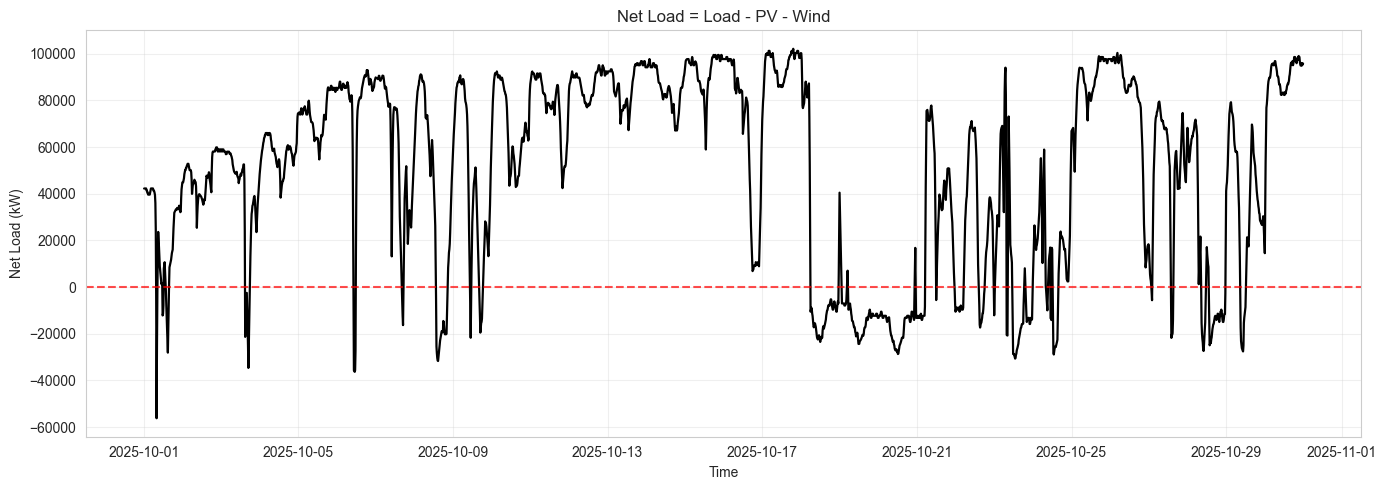

In [95]:
df["NetLoad_kw"] = df["P_kw"] - df["PV_kw"] - df["Wind_kw"]
df_NetLoad_kw = df[
    (df["Time"] > start) &
    (df["Time"] < end)
]
plt.figure(figsize=(14, 5))

plt.plot(df["Time"], df_NetLoad_kw["NetLoad_kw"], color="black", linewidth=1.6)

plt.axhline(0, linestyle="--", color="red", alpha=0.7)

plt.xlabel("Time")
plt.ylabel("Net Load (kW)")
plt.title("Net Load = Load - PV - Wind")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [96]:
df.to_csv("df_total.csv")

In [121]:
cfg_pv = PlanConfigFastWind(
    # -------- 约束 --------
    self_use_ratio_min=0.60,
    load_cover_ratio_min=0.30,
    # -------- 成本 --------
    pv_capex_yuan_per_kwp=2000.0,
    bess_capex_yuan_per_kwh=1000.0,
    # -------- PV 搜索 --------
    pv_step_coarse_kwp=1000.0,
    pv_step_fine_kwp=250.0,
    pv_refine_window_kwp=8000.0,

    eta_roundtrip=0.92,
    c_rate=0.5,
    soc_init_frac=0.5,

    enable_bess=True,          # 需要储能就 True；只规划PV则 False
    batt_hi_init_kwh=1000.0,
    batt_bisect_iter=22,

    use_numba=True
)

In [156]:
import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import Optional, Dict, Any, Tuple, Union

# ============================================================
# 可选：Numba
# ============================================================
try:
    from numba import njit
    NUMBA_OK = True
except Exception:
    NUMBA_OK = False
    def njit(*args, **kwargs):
        def deco(f): return f
        return deco


# ============================================================
# 单位配置（工程强烈推荐）
# ============================================================
@dataclass
class UnitsConfig:
    """
    内部统一单位：
      功率: kW
      电量: kWh
      时间: hour
    """
    load_power: str = "kW"     # kW / MW
    pv_power: str = "kW"       # kW/kWp（unit curve）
    wind_power: str = "MW"     # MW / kW


# ============================================================
# 全量规划配置 cfg
# ============================================================
@dataclass
class PlanConfigFast:
    # ---------- 成本 ----------
    pv_capex_yuan_per_kwp: float = 2000.0
    bess_capex_yuan_per_kwh: float = 1000.0

    # ---------- 储能物理 ----------
    eta_roundtrip: float = 0.92
    c_rate: float = 0.5
    soc_init_frac: float = 0.5
    soc_min_frac: float = 0.1
    soc_max_frac: float = 1.0

    # ---------- 约束 ----------
    self_use_ratio_min: float = 0.6
    load_cover_ratio_min: float = 0.2

    constraint_mode: str = "annual"     # annual / monthly
    monthly_all_must_meet: bool = True

    # ---------- PV 搜索 ----------
    pv_min_kwp: float = 0.0
    pv_step_coarse_kwp: float = 2000.0
    pv_step_fine_kwp: float = 250.0
    pv_refine_window_kwp: float = 8000.0
    pv_max_kwp: Optional[float] = None

    # ---------- 储能搜索 ----------
    enable_bess: bool = True
    batt_hi_init_kwh: float = 500.0
    batt_hi_max_kwh: float = 1e7
    batt_bisect_iter: int = 26
    batt_tol_kwh: float = 1.0

    # ---------- 工程 ----------
    use_numba: bool = True


# ============================================================
# 工具函数
# ============================================================
def infer_dt_hours(t) -> float:
    """
    输入：
      t: pd.Series 或 DatetimeIndex（时间轴）

    输出：
      dt_hours: float
    """

    # ===== 统一转为 Series（关键）=====
    if isinstance(t, pd.DatetimeIndex):
        t = pd.Series(t)
    else:
        t = pd.Series(pd.to_datetime(t))

    t = t.sort_values().reset_index(drop=True)

    if len(t) < 2:
        raise ValueError("时间点数量不足，无法推断 dt")

    dt = t.diff().dropna().mode().iloc[0]
    return float(dt.total_seconds() / 3600.0)


def normalize_time_and_load(
    df: pd.DataFrame,
    time_col: str,
    load_col: str,
    units: UnitsConfig,
) -> Tuple[pd.Series, np.ndarray, list]:

    print("### normalize_time_and_load FIXED VERSION CALLED")
    warnings = []

    if load_col not in df.columns:
        raise KeyError(f"负荷列 {load_col} 不存在")

    # ---------- 时间轴 ----------
    if time_col in df.columns:
        t = pd.to_datetime(df[time_col]).copy()
    elif isinstance(df.index, pd.DatetimeIndex):
        t = pd.Series(pd.to_datetime(df.index), name="Time")
        warnings.append("使用 DatetimeIndex 作为时间轴")
    else:
        raise ValueError("未找到时间列，且 index 不是 DatetimeIndex")

    # ---------- 负荷 ----------
    load = pd.to_numeric(df[load_col], errors="coerce").fillna(0.0).to_numpy(dtype=float)

    # ---------- 单位换算 ----------
    if units.load_power.lower() == "mw":
        load = load * 1000.0

    # ---------- 排序（关键：只对 Series reset_index） ----------
    order = np.argsort(t.values)
    t = t.iloc[order].reset_index(drop=True)
    load = load[order]

    # ---------- 诊断 ----------
    if load.max() < 10:
        warnings.append("负荷峰值 <10kW，疑似单位错误")

    return t, load, warnings




def as_time_series(
    x: Union[pd.Series, pd.DataFrame],
    time_col: str,
    value_cols: Tuple[str, ...],
    scale: float,
) -> pd.Series:
    if isinstance(x, pd.Series):
        s = x.copy()
        s.index = pd.to_datetime(s.index)
        return pd.to_numeric(s, errors="coerce").fillna(0.0) * scale

    df = x.copy()
    if time_col in df.columns:
        t = pd.to_datetime(df[time_col])
        df = df.drop(columns=[time_col])
    else:
        t = pd.to_datetime(df.index)

    for c in value_cols:
        if c in df.columns:
            s = pd.to_numeric(df[c], errors="coerce").fillna(0.0)
            s.index = t
            return s * scale

    raise ValueError("未找到数值列")


def align_to_time(t: pd.Series, s: pd.Series) -> np.ndarray:
    return (
        s.reindex(pd.DatetimeIndex(t))
        .interpolate("time")
        .fillna(0.0)
        .to_numpy(dtype=float)
    )


# ============================================================
# 调度（PV + 风 + 储能）
# ============================================================
@njit
def dispatch_numba(load_kw, gen_kw, dt, batt_kwh, eta, c_rate, soc0, soc_min_f, soc_max_f):
    gen_e = used_e = load_e = bess_dis = 0.0

    if batt_kwh <= 0:
        for i in range(load_kw.shape[0]):
            L = max(load_kw[i], 0)
            G = max(gen_kw[i], 0)
            load_e += L * dt
            gen_e += G * dt
            used_e += min(L, G) * dt
        return gen_e, used_e, load_e, bess_dis

    soc = soc0 * batt_kwh
    soc_min = soc_min_f * batt_kwh
    soc_max = soc_max_f * batt_kwh
    pmax = c_rate * batt_kwh
    eta_c = eta ** 0.5
    eta_d = eta ** 0.5

    for i in range(load_kw.shape[0]):
        L = max(load_kw[i], 0)
        G = max(gen_kw[i], 0)
        load_e += L * dt
        gen_e += G * dt

        direct = min(L, G)
        used_e += direct * dt

        surplus = G - direct
        deficit = L - direct

        if surplus > 1e-9 and soc < soc_max:
            ch = min(surplus, pmax, (soc_max - soc) / dt)
            soc += ch * dt * eta_c

        if deficit > 1e-9 and soc > soc_min:
            dis = min(deficit, pmax, (soc - soc_min) * eta_d / dt)
            soc -= dis * dt / eta_d
            used_e += dis * dt
            bess_dis += dis * dt

    return gen_e, used_e, load_e, bess_dis


def evaluate(load_kw, gen_kw, dt, batt_kwh, cfg: PlanConfigFast) -> Dict[str, float]:
    if cfg.use_numba and NUMBA_OK:
        g, u, l, b = dispatch_numba(
            load_kw, gen_kw, dt, batt_kwh,
            cfg.eta_roundtrip, cfg.c_rate,
            cfg.soc_init_frac, cfg.soc_min_frac, cfg.soc_max_frac
        )
    else:
        g = gen_kw.sum() * dt
        l = load_kw.sum() * dt
        u = np.minimum(load_kw, gen_kw).sum() * dt
        b = 0.0

    return {
        "gen_kwh": g,
        "used_kwh": u,
        "load_kwh": l,
        "self_use_ratio": u / g if g > 1e-9 else 0.0,
        "load_cover_ratio": u / l if l > 1e-9 else 0.0,
        "bess_discharge_kwh": b,
    }


# ============================================================
# 主规划函数（最终版）
# ============================================================
def plan_energy_system(
    df_load: pd.DataFrame,
    *,
    pv_unit_kw: Optional[Union[pd.Series, pd.DataFrame]] = None,
    wind_input: Optional[Union[pd.Series, pd.DataFrame]] = None,
    time_col: str = "Time",
    load_col: str = "P_kw",
    cfg: PlanConfigFast = PlanConfigFast(),
    units: UnitsConfig = UnitsConfig(),
) -> Dict[str, Any]:

    # ---------- 负荷 ----------
    # try:
    #     t, load_kw, load_warn = normalize_time_and_load(
    #         df_load, time_col, load_col, units
    #     )
    # except Exception as e:
    #     return {"feasible": False, "diagnosis": {"reason": "INVALID_LOAD", "msg": str(e)}}
    t, load_kw, load_warn = normalize_time_and_load(df_load, time_col, load_col, units)
    dt = infer_dt_hours(t)

    # ---------- 风 ----------
    wind_kw = np.zeros_like(load_kw)
    if wind_input is not None:
        scale = 1000.0 if units.wind_power.lower() == "mw" else 1.0
        w = as_time_series(
            wind_input, time_col,
            ("WindPower_MW", "wind_mw", "wind_kw"),
            scale
        )
        wind_kw = align_to_time(t, w)

    # ---------- PV ----------
    pv_kw = np.zeros_like(load_kw)
    if pv_unit_kw is not None:
        pu = as_time_series(
            pv_unit_kw, time_col,
            ("pv_unit_kw", "pv_kw", "value"),
            1.0
        )
        pv_kw = align_to_time(t, pu)

    # ---------- 总新能源 ----------
    gen_kw = wind_kw + pv_kw

    # ---------- 仅储能场景 ----------
    if pv_unit_kw is None and wind_input is None:
        return {
            "feasible": False,
            "diagnosis": {
                "reason": "NO_GENERATION",
                "message": "无 PV / 无风，仅储能无法创造能量，仅可做移峰套利"
            }
        }

    # ---------- 储能搜索 ----------
    best = None
    for batt in np.linspace(0, cfg.batt_hi_max_kwh, 40):
        stats = evaluate(load_kw, gen_kw, dt, batt, cfg)
        if (
            stats["self_use_ratio"] >= cfg.self_use_ratio_min and
            stats["load_cover_ratio"] >= cfg.load_cover_ratio_min
        ):
            cost = batt * cfg.bess_capex_yuan_per_kwh
            if best is None or cost < best["cost"]:
                best = {"bess_kwh": batt, "metrics": stats, "cost": cost}

    if best is None:
        return {
            "feasible": False,
            "diagnosis": {
                "reason": "NO_FEASIBLE_SOLUTION",
                "self_use_ratio_min": cfg.self_use_ratio_min,
                "load_cover_ratio_min": cfg.load_cover_ratio_min,
            }
        }

    return {
        "feasible": True,
        "solution": best,
        "warnings": load_warn,
        "context": {
            "dt_hours": dt,
            "engine": "numba" if (cfg.use_numba and NUMBA_OK) else "python",
        }
    }


In [157]:
cfg_ess = PlanConfigFast(
    self_use_ratio_min=0.6,
    load_cover_ratio_min=0.3,
    enable_bess=True,
    batt_hi_max_kwh=2e5,
)

units = UnitsConfig(
    load_power="kW",
    wind_power="MW",
)



In [158]:
res_ess = plan_energy_system(
    df_load=df_load,
    wind_input=df_wind,
    time_col="Time",
    load_col="P_kw",
    cfg=cfg,
    units=units,
)

### normalize_time_and_load FIXED VERSION CALLED


In [159]:
print(res)

{'feasible': False, 'diagnosis': {'reason': 'INVALID_LOAD', 'msg': "'DatetimeIndex' object has no attribute 'reset_index'"}}


In [ ]:
print(res["pv_kwp"], res["bess_kwh"], res["debug"]["pv_profile_missing"])


### 风光储最佳组合测算

In [38]:
import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import Optional, Dict, Any, Tuple, Union

# ============================================================
# 可选：Numba
# ============================================================
try:
    from numba import njit
    NUMBA_OK = True
except Exception:
    NUMBA_OK = False
    def njit(*args, **kwargs):
        def deco(f): return f
        return deco


# ============================================================
# 调试工具
# ============================================================
def dbg(msg: str, obj: Any = None):
    print(f"[DBG] {msg}")
    if obj is not None:
        try:
            print("      type:", type(obj))
            if isinstance(obj, (pd.Series, pd.Index, pd.DatetimeIndex)):
                print("      len :", len(obj))
                print("      head:", list(obj[:3]))
            elif isinstance(obj, pd.DataFrame):
                print("      shape:", obj.shape)
                print("      columns:", list(obj.columns))
                print("      index type:", type(obj.index))
        except Exception as e:
            print("      (dbg failed):", e)


# ============================================================
# 单位配置
# ============================================================
@dataclass
class UnitsConfig:
    load_power: str = "kW"     # kW / MW
    pv_power: str = "kW"       # kW
    wind_power: str = "MW"     # MW / kW


# ============================================================
# 全量规划配置
# ============================================================
@dataclass
class PlanConfigFast:
    bess_capex_yuan_per_kwh: float = 1000.0

    eta_roundtrip: float = 0.92
    c_rate: float = 0.5
    soc_init_frac: float = 0.5
    soc_min_frac: float = 0.1
    soc_max_frac: float = 1.0

    self_use_ratio_min: float = 0.6
    load_cover_ratio_min: float = 0.2

    batt_hi_max_kwh: float = 20000.0
    use_numba: bool = True


# ============================================================
# 时间工具（100% 防 Index）
# ============================================================
def infer_dt_hours(t) -> float:
    dbg("infer_dt_hours input", t)

    t = pd.Series(pd.to_datetime(t), name="Time")
    t = t.sort_values().reset_index(drop=True)

    if len(t) < 2:
        raise ValueError("时间点数量不足")

    dt = t.diff().dropna().mode().iloc[0]
    dt_hours = dt.total_seconds() / 3600.0
    dbg(f"infer_dt_hours dt_hours={dt_hours}")
    return dt_hours


# ============================================================
# 负荷 + 时间轴规范化（终极安全版）
# ============================================================
def normalize_time_and_load(
    df: pd.DataFrame,
    time_col: str,
    load_col: str,
    units: UnitsConfig,
) -> Tuple[pd.Series, np.ndarray, list]:

    print("### normalize_time_and_load CALLED")
    warnings = []

    dbg("input df", df)

    if not isinstance(df, pd.DataFrame):
        raise TypeError(f"df_load 类型错误：{type(df)}")

    if load_col not in df.columns:
        raise KeyError(f"负荷列 {load_col} 不存在")

    # ---------- 时间轴 ----------
    if time_col in df.columns:
        raw_t = df[time_col]
        dbg("raw time_col", raw_t)
        t = pd.Series(pd.to_datetime(raw_t), name="Time")
    elif isinstance(df.index, pd.DatetimeIndex):
        t = pd.Series(pd.to_datetime(df.index), name="Time")
        warnings.append("使用 DatetimeIndex 作为时间轴")
    else:
        raise ValueError("未找到时间列")

    assert isinstance(t, pd.Series), f"t 类型异常：{type(t)}"

    # ---------- 负荷 ----------
    load = pd.to_numeric(df[load_col], errors="coerce").fillna(0.0).to_numpy(dtype=float)

    if units.load_power.lower() == "mw":
        load *= 1000.0

    # ---------- 排序 ----------
    order = np.argsort(t.values)
    t = t.iloc[order].reset_index(drop=True)
    load = load[order]

    dbg("normalized t", t)
    dbg("normalized load", load[:5])

    return t, load, warnings


# ============================================================
# 发电输入规范化
# ============================================================
def as_time_series(
    x: Union[pd.Series, pd.DataFrame],
    time_col: str,
    value_cols: Tuple[str, ...],
    scale: float,
) -> pd.Series:

    dbg("as_time_series input", x)

    if isinstance(x, pd.Series):
        s = pd.to_numeric(x, errors="coerce").fillna(0.0)
        s.index = pd.to_datetime(s.index)
        return s * scale

    if not isinstance(x, pd.DataFrame):
        raise TypeError("输入必须是 Series 或 DataFrame")

    if time_col in x.columns:
        t = pd.to_datetime(x[time_col])
        df = x.drop(columns=[time_col])
    else:
        t = pd.to_datetime(x.index)
        df = x.copy()

    for c in value_cols:
        if c in df.columns:
            s = pd.to_numeric(df[c], errors="coerce").fillna(0.0)
            s.index = t
            return s * scale

    raise ValueError("未找到有效数值列")


def align_to_time(t: pd.Series, s: pd.Series) -> np.ndarray:
    return (
        s.reindex(pd.DatetimeIndex(t))
        .interpolate("time")
        .fillna(0.0)
        .to_numpy(dtype=float)
    )


# ============================================================
# 调度
# ============================================================
@njit
def dispatch_numba(load_kw, gen_kw, dt, batt_kwh, eta, c_rate, soc0, soc_min_f, soc_max_f):
    gen_e = used_e = load_e = bess_dis = 0.0

    if batt_kwh <= 0:
        for i in range(load_kw.shape[0]):
            L = max(load_kw[i], 0)
            G = max(gen_kw[i], 0)
            load_e += L * dt
            gen_e += G * dt
            used_e += min(L, G) * dt
        return gen_e, used_e, load_e, bess_dis

    soc = soc0 * batt_kwh
    soc_min = soc_min_f * batt_kwh
    soc_max = soc_max_f * batt_kwh
    pmax = c_rate * batt_kwh
    eta_c = eta ** 0.5
    eta_d = eta ** 0.5

    for i in range(load_kw.shape[0]):
        L = max(load_kw[i], 0)
        G = max(gen_kw[i], 0)
        load_e += L * dt
        gen_e += G * dt

        direct = min(L, G)
        used_e += direct * dt

        surplus = G - direct
        deficit = L - direct

        if surplus > 1e-9 and soc < soc_max:
            ch = min(surplus, pmax, (soc_max - soc) / dt)
            soc += ch * dt * eta_c

        if deficit > 1e-9 and soc > soc_min:
            dis = min(deficit, pmax, (soc - soc_min) * eta_d / dt)
            soc -= dis * dt / eta_d
            used_e += dis * dt
            bess_dis += dis * dt

    return gen_e, used_e, load_e, bess_dis


def evaluate(load_kw, gen_kw, dt, batt_kwh, cfg: PlanConfigFast) -> Dict[str, float]:
    if cfg.use_numba and NUMBA_OK:
        g, u, l, b = dispatch_numba(
            load_kw, gen_kw, dt, batt_kwh,
            cfg.eta_roundtrip, cfg.c_rate,
            cfg.soc_init_frac, cfg.soc_min_frac, cfg.soc_max_frac
        )
    else:
        g = gen_kw.sum() * dt
        l = load_kw.sum() * dt
        u = np.minimum(load_kw, gen_kw).sum() * dt
        b = 0.0

    return {
        "gen_kwh": g,
        "used_kwh": u,
        "load_kwh": l,
        "self_use_ratio": u / g if g > 1e-9 else 0.0,
        "load_cover_ratio": u / l if l > 1e-9 else 0.0,
        "bess_discharge_kwh": b,
    }


# ============================================================
# 主入口
# ============================================================
def plan_energy_system(
    df_load: pd.DataFrame,
    *,
    pv_unit_kw: Optional[Union[pd.Series, pd.DataFrame]] = None,
    wind_input: Optional[Union[pd.Series, pd.DataFrame]] = None,
    time_col: str = "Time",
    load_col: str = "P_kw",
    cfg: PlanConfigFast = PlanConfigFast(),
    units: UnitsConfig = UnitsConfig(),
) -> Dict[str, Any]:

    try:
        dbg("ENTER plan_energy_system df_load", df_load)
        t, load_kw, warn = normalize_time_and_load(df_load, time_col, load_col, units)
        dt = infer_dt_hours(t)
    except Exception as e:
        return {
            "feasible": False,
            "diagnosis": {"stage": "load", "msg": str(e)}
        }

    wind_kw = np.zeros_like(load_kw)
    if wind_input is not None:
        try:
            w = as_time_series(
                wind_input, time_col,
                ("WindPower_MW", "wind_mw", "wind_kw"),
                1000.0 if units.wind_power.lower() == "mw" else 1.0
            )
            wind_kw = align_to_time(t, w)
        except Exception as e:
            return {"feasible": False, "diagnosis": {"stage": "wind", "msg": str(e)}}

    pv_kw = np.zeros_like(load_kw)
    if pv_unit_kw is not None:
        try:
            p = as_time_series(
                pv_unit_kw, time_col,
                ("pv_unit_kw", "pv_kw", "value"),
                1.0
            )
            pv_kw = align_to_time(t, p)
        except Exception as e:
            return {"feasible": False, "diagnosis": {"stage": "pv", "msg": str(e)}}

    gen_kw = wind_kw + pv_kw

    if pv_unit_kw is None and wind_input is None:
        return {
            "feasible": False,
            "diagnosis": {
                "reason": "NO_GENERATION",
                "msg": "无 PV / 无风，仅储能不能创造能量"
            }
        }

    best = None
    for batt in np.linspace(0, cfg.batt_hi_max_kwh, 40):
        stats = evaluate(load_kw, gen_kw, dt, batt, cfg)
        if (
            stats["self_use_ratio"] >= cfg.self_use_ratio_min and
            stats["load_cover_ratio"] >= cfg.load_cover_ratio_min
        ):
            cost = batt * cfg.bess_capex_yuan_per_kwh
            if best is None or cost < best["cost"]:
                best = {"bess_kwh": batt, "metrics": stats, "cost": cost}

    if best is None:
        return {
            "feasible": False,
            "diagnosis": {
                "reason": "NO_FEASIBLE_SOLUTION",
                "self_use_ratio_min": cfg.self_use_ratio_min,
                "load_cover_ratio_min": cfg.load_cover_ratio_min,
            }
        }

    return {
        "feasible": True,
        "solution": best,
        "warnings": warn,
        "context": {
            "dt_hours": dt,
            "engine": "numba" if (cfg.use_numba and NUMBA_OK) else "python"
        }
    }


In [40]:
res = plan_energy_system(
    df_load=df_2025,
    wind_input=df_wind,
    time_col="Time",
    load_col="P_kw",
)

[DBG] ENTER plan_energy_system df_load
      type: <class 'pandas.core.frame.DataFrame'>
      shape: (35040, 2)
      columns: ['Time', 'P_kw']
      index type: <class 'pandas.core.indexes.range.RangeIndex'>
### normalize_time_and_load CALLED
[DBG] input df
      type: <class 'pandas.core.frame.DataFrame'>
      shape: (35040, 2)
      columns: ['Time', 'P_kw']
      index type: <class 'pandas.core.indexes.range.RangeIndex'>
[DBG] raw time_col
      type: <class 'pandas.core.series.Series'>
      len : 35040
      head: [Timestamp('2025-01-01 00:00:00'), Timestamp('2025-01-01 00:15:00'), Timestamp('2025-01-01 00:30:00')]
[DBG] normalized t
      type: <class 'pandas.core.series.Series'>
      len : 35040
      head: [Timestamp('2025-01-01 00:00:00'), Timestamp('2025-01-01 00:15:00'), Timestamp('2025-01-01 00:30:00')]
[DBG] normalized load
      type: <class 'numpy.ndarray'>
[DBG] infer_dt_hours input
      type: <class 'pandas.core.series.Series'>
      len : 35040
      head: [Times

In [41]:
print(df_2025.dtypes)
print(df_wind.dtypes)

Time    datetime64[ns]
P_kw           float64
dtype: object
WindPower_MW    float64
dtype: object


In [64]:
import os
from dataclasses import dataclass
from typing import Optional, Dict, Any, Tuple, Union

import numpy as np
import pandas as pd


# ============================================================
# 1) 配置
# ============================================================

@dataclass
class BESSConfig:
    eta_charge: float = 0.92
    eta_discharge: float = 0.92
    soc_min: float = 0.10
    soc_max: float = 1.00
    soc_init: float = 0.50

    # 功率上限：Pmax(kW) = c_rate * E(kWh)
    c_rate: float = 1.0

    # 是否强制期末 SOC 回到初始（避免“年末把电池放空”虚增覆盖率）
    enforce_terminal_soc: bool = True


@dataclass
class Targets:
    min_green_self_consumption: float = 0.60  # served / wind
    min_load_coverage: float = 0.30           # served / load


@dataclass
class Investment:
    capex_cny_per_kwh: float = 1000.0


@dataclass
class ShiftPolicy:
    """
    允许在 Wind < Load 时也能充电平移（通过牺牲当期供电来换未来供电）。
    - enable_shift: 是否开启
    - lookahead_steps: 未来窗口长度（用于判断是否“值得”储能平移）
    - shift_max_frac_of_wind: 当 Wind<Load 时，最多拿走 wind 的多少比例去充电
    说明：
      这会减少当期 served，但可能提升未来某些时段的 served（更符合“平移”直觉）。
      若你只关心总覆盖率/自用率，理论上它不一定更优，但你明确要求支持该行为。
    """
    enable_shift: bool = True
    lookahead_steps: int = 8
    shift_max_frac_of_wind: float = 0.30


# ============================================================
# 2) 读入与对齐（支持 DataFrame 或文件路径；Time 列或 DatetimeIndex）
# ============================================================

def read_timeseries(obj: Union[str, pd.DataFrame]) -> pd.DataFrame:
    if isinstance(obj, pd.DataFrame):
        df = obj.copy()
    elif isinstance(obj, str):
        ext = os.path.splitext(obj.lower())[1]
        if ext in [".csv", ".txt"]:
            df = pd.read_csv(obj)
        elif ext in [".xlsx", ".xls"]:
            df = pd.read_excel(obj)
        else:
            raise ValueError(f"Unsupported file extension: {ext}")
    else:
        raise TypeError("Input must be a DataFrame or a file path (str).")

    if "Time" in df.columns:
        df["Time"] = pd.to_datetime(df["Time"])
    elif isinstance(df.index, pd.DatetimeIndex):
        idx_name = df.index.name or "index"
        df = df.reset_index().rename(columns={idx_name: "Time"})
        df["Time"] = pd.to_datetime(df["Time"])
    else:
        raise ValueError("Input must have a 'Time' column or a DatetimeIndex.")

    df = df.sort_values("Time").reset_index(drop=True)
    return df


def infer_freq_minutes(time_index: pd.DatetimeIndex) -> int:
    if len(time_index) < 2:
        return 15
    diffs = np.diff(time_index.view("i8"))  # ns
    diffs = diffs[diffs > 0]
    if len(diffs) == 0:
        return 15
    med_ns = np.median(diffs)
    return max(1, int(round(med_ns / 1e9 / 60.0)))


def align_and_merge(
    df_load: pd.DataFrame,
    df_wind: pd.DataFrame,
    load_col_kw: str = "P_kw",
    wind_col_mw: str = "WindPower_MW",
    freq: Optional[str] = None,
) -> Tuple[pd.DataFrame, float]:
    if load_col_kw not in df_load.columns:
        raise ValueError(f"Load missing column: {load_col_kw}")
    if wind_col_mw not in df_wind.columns:
        raise ValueError(f"Wind missing column: {wind_col_mw}")

    dfl = df_load[["Time", load_col_kw]].rename(columns={load_col_kw: "Load_kW"}).copy()
    dfw = df_wind[["Time", wind_col_mw]].rename(columns={wind_col_mw: "WindPower_MW"}).copy()
    dfw["Wind_kW"] = dfw["WindPower_MW"].astype(float) * 1000.0
    dfw = dfw.drop(columns=["WindPower_MW"])

    dfl = dfl.set_index("Time")
    dfw = dfw.set_index("Time")

    if freq is None:
        mins = min(infer_freq_minutes(dfl.index), infer_freq_minutes(dfw.index))
        freq = f"{mins}min"

    idx = pd.date_range(
        start=max(dfl.index.min(), dfw.index.min()),
        end=min(dfl.index.max(), dfw.index.max()),
        freq=freq
    )

    dfl = dfl.reindex(idx).interpolate("time").ffill().bfill()
    dfw = dfw.reindex(idx).interpolate("time").ffill().bfill()

    df = pd.concat([dfl, dfw], axis=1)
    dt_h = pd.to_timedelta(freq).total_seconds() / 3600.0
    return df, float(dt_h)


# ============================================================
# 3) 快速“必要可行性”诊断（避免无解时慢扫容量）
# ============================================================

def quick_feasibility_diagnose(
    load_kw: np.ndarray,
    wind_kw: np.ndarray,
    dt_h: float,
    targets: Targets,
    bess: BESSConfig,
) -> Dict[str, float]:
    """
    给出几个关键上界/必要条件：
    - 能量比 wind/load
    - 可用于充电的“富余能量”比例 surplus/load
    - 在“只能用富余充电”的前提下，理论最大 served 上界：direct + eta_rt*surplus
    """
    e_load = float(load_kw.sum() * dt_h)
    e_wind = float(wind_kw.sum() * dt_h)

    direct = np.minimum(load_kw, wind_kw)
    surplus = np.maximum(wind_kw - load_kw, 0.0)

    e_direct = float(direct.sum() * dt_h)
    e_surplus = float(surplus.sum() * dt_h)

    eta_rt = bess.eta_charge * bess.eta_discharge

    # “只用富余充电”的理论 served 上界
    e_served_upper_surplus_only = e_direct + eta_rt * e_surplus

    return {
        "wind_load_ratio": (e_wind / e_load) if e_load > 0 else 0.0,
        "surplus_load_ratio": (e_surplus / e_load) if e_load > 0 else 0.0,
        "served_upper_surplus_only_ratio": (e_served_upper_surplus_only / e_load) if e_load > 0 else 0.0,
        "green_self_upper_surplus_only": (e_served_upper_surplus_only / e_wind) if e_wind > 0 else 0.0,
    }


# ============================================================
# 4) 调度仿真（核心：支持“Wind<Load 也可充电平移”，且禁止电网充电）
# ============================================================

def simulate_dispatch_offgrid_shiftable(
    load_kw: np.ndarray,
    wind_kw: np.ndarray,
    dt_h: float,
    cap_mwh: float,
    bess: BESSConfig,
    policy: ShiftPolicy,
) -> Dict[str, Any]:
    """
    决策逻辑（快仿真）：
      - 每步风电 W：
          分为：供负荷 + 充电 + 弃电
        电池放电仅用于供负荷，不允许外部电网充电
      - 允许 Wind < Load 时拿走一部分 wind 去充电（平移），导致当期供电下降
        触发条件：未来 lookahead 窗口内存在明显“缺口压力”，且 SOC 有空间
    """
    n = len(load_kw)
    cap_kwh = cap_mwh * 1000.0

    # 无储能：直接用风供负荷
    if cap_kwh <= 0:
        served = np.minimum(wind_kw, load_kw)
        curtail = np.maximum(wind_kw - served, 0.0)
        soc = np.full(n, bess.soc_init, dtype=float)
        charge = np.zeros(n, dtype=float)
        discharge = np.zeros(n, dtype=float)
        return _post_metrics(served, load_kw, wind_kw, charge, discharge, soc, curtail, dt_h, cap_mwh)

    pmax = bess.c_rate * cap_kwh

    soc = np.zeros(n, dtype=float)
    charge = np.zeros(n, dtype=float)
    discharge = np.zeros(n, dtype=float)
    served = np.zeros(n, dtype=float)
    curtail = np.zeros(n, dtype=float)

    e = bess.soc_init * cap_kwh  # 用 kWh 表示能量状态

    soc_min_e = bess.soc_min * cap_kwh
    soc_max_e = bess.soc_max * cap_kwh

    look = max(1, int(policy.lookahead_steps))

    # 预计算“净负荷压力”用于触发平移：net = load - wind
    net = load_kw - wind_kw

    for t in range(n):
        L = float(max(0.0, load_kw[t]))
        W = float(max(0.0, wind_kw[t]))

        # 可充电空间、可放电能量
        room = max(0.0, soc_max_e - e)
        avail = max(0.0, e - soc_min_e)

        # 功率上限（kW）
        ch_max = min(pmax, room / (bess.eta_charge * dt_h)) if room > 0 else 0.0
        dis_max_out = min(pmax, (avail * bess.eta_discharge) / dt_h) if avail > 0 else 0.0

        # ===== 1) 先决定是否“平移充电”（即使 Wind<Load） =====
        ch_plan = 0.0
        if policy.enable_shift and ch_max > 0 and W > 0:
            # 未来缺口压力（只看未来 net>0 的总量）
            t2 = min(n, t + look)
            future_def = float(np.maximum(net[t:t2], 0.0).sum())

            # 若未来缺口明显，且当前 SOC 低于中位水平，则允许抽取部分风去充电
            # 这里用一个简洁触发：future_def 大于当前负荷的若干倍
            soc_ratio = e / cap_kwh
            if future_def > 0.5 * L * (t2 - t) and soc_ratio < 0.7:
                # 抽取 wind 的一部分去充电（但不能超过 ch_max）
                ch_plan = min(ch_max, policy.shift_max_frac_of_wind * W)

        # ===== 2) 风电分配：先预留 ch_plan，然后用剩余 wind 供负荷 =====
        W_after_ch = max(0.0, W - ch_plan)
        serve_from_wind = min(L, W_after_ch)

        # ===== 3) 若风电仍不足，电池放电补缺口 =====
        deficit = L - serve_from_wind
        dis_out = min(dis_max_out, max(0.0, deficit))

        served_t = serve_from_wind + dis_out

        # ===== 4) 充电：除了 ch_plan，若有富余 wind，也可继续充电 =====
        # 富余 wind = W - serve_from_wind - ch_plan （注意 serve_from_wind 用的是 W_after_ch）
        # 实际剩余 = W - serve_from_wind - ch_plan
        surplus = max(0.0, W - serve_from_wind - ch_plan)

        ch_extra = min(max(0.0, ch_max - ch_plan), surplus)
        ch_in = ch_plan + ch_extra  # 总充电功率（来自风电，不允许电网）

        # ===== 5) 弃电 =====
        curtail_t = max(0.0, W - serve_from_wind - ch_in)

        # ===== 6) 更新能量 e（kWh） =====
        e += (ch_in * bess.eta_charge - dis_out / bess.eta_discharge) * dt_h
        e = float(np.clip(e, soc_min_e, soc_max_e))

        charge[t] = ch_in
        discharge[t] = dis_out
        served[t] = served_t
        curtail[t] = curtail_t
        soc[t] = e / cap_kwh

    # ===== 期末 SOC 约束（快速近似修正：不满足则判为更严格的“不可行”）=====
    if bess.enforce_terminal_soc:
        if abs(soc[-1] - bess.soc_init) > 0.02:  # 允许小偏差
            # 这种情况下，当前容量在“闭环运行”意义下偏乐观
            # 直接标记为不满足（便于二分搜索收敛到更大容量）
            res = _post_metrics(served, load_kw, wind_kw, charge, discharge, soc, curtail, dt_h, cap_mwh)
            res["terminal_soc_ok"] = False
            return res

    res = _post_metrics(served, load_kw, wind_kw, charge, discharge, soc, curtail, dt_h, cap_mwh)
    res["terminal_soc_ok"] = True
    return res


def _post_metrics(
    served_kw: np.ndarray,
    load_kw: np.ndarray,
    wind_kw: np.ndarray,
    charge_kw: np.ndarray,
    discharge_kw: np.ndarray,
    soc: np.ndarray,
    curtail_kw: np.ndarray,
    dt_h: float,
    cap_mwh: float,
) -> Dict[str, Any]:
    e_load = float(load_kw.sum() * dt_h)
    e_wind = float(wind_kw.sum() * dt_h)
    e_served = float(served_kw.sum() * dt_h)
    e_curtail = float(curtail_kw.sum() * dt_h)

    green_self = (e_served / e_wind) if e_wind > 0 else 0.0
    coverage = (e_served / e_load) if e_load > 0 else 0.0

    cap_kwh = cap_mwh * 1000.0
    e_dis = float(discharge_kw.sum() * dt_h)
    equiv_cycles = (e_dis / cap_kwh) if cap_kwh > 0 else 0.0

    return {
        "cap_mwh": float(cap_mwh),
        "energy_kwh": {
            "load": e_load,
            "wind": e_wind,
            "served": e_served,
            "curtail": e_curtail,
            "charge_in": float(charge_kw.sum() * dt_h),
            "discharge_out": float(discharge_kw.sum() * dt_h),
        },
        "metrics": {
            "green_self_consumption": float(green_self),
            "load_coverage": float(coverage),
            "equiv_cycles": float(equiv_cycles),
        },
        "series": {
            "served_kw": served_kw,
            "charge_kw": charge_kw,
            "discharge_kw": discharge_kw,
            "soc": soc,
            "curtail_kw": curtail_kw,
        }
    }


# ============================================================
# 5) 最小投资（最小容量）求解：二分搜索（速度提升关键）
# ============================================================

def is_feasible(res: Dict[str, Any], targets: Targets) -> bool:
    m = res["metrics"]
    ok = (m["green_self_consumption"] >= targets.min_green_self_consumption and
          m["load_coverage"] >= targets.min_load_coverage)
    # 若启用期末 SOC 闭环要求，则必须 ok
    if "terminal_soc_ok" in res and (res["terminal_soc_ok"] is False):
        return False
    return ok


def find_min_capacity_bisect(
    load_kw: np.ndarray,
    wind_kw: np.ndarray,
    dt_h: float,
    targets: Targets,
    bess: BESSConfig,
    inv: Investment,
    policy: ShiftPolicy,
    cap_max_mwh: float = 2000.0,
    tol_mwh: float = 0.1,
) -> Dict[str, Any]:
    """
    单调性说明（工程上成立）：
      容量越大，能搬运的能量越多，覆盖率与自用率不会变差（在我们这个策略下基本单调）。
    因此可用二分搜索最小可行容量。
    """

    # 先快速找一个可行上界
    lo = 0.0
    hi = 1.0
    best = None

    while hi <= cap_max_mwh + 1e-9:
        res = simulate_dispatch_offgrid_shiftable(load_kw, wind_kw, dt_h, hi, bess, policy)
        if is_feasible(res, targets):
            best = res
            break
        hi *= 2.0

    if best is None:
        raise RuntimeError(
            f"No feasible solution up to cap_max_mwh={cap_max_mwh}. "
            f"Try increasing cap_max_mwh or relaxing targets."
        )

    # 二分搜索
    while (hi - lo) > tol_mwh:
        mid = (lo + hi) / 2.0
        res = simulate_dispatch_offgrid_shiftable(load_kw, wind_kw, dt_h, mid, bess, policy)
        if is_feasible(res, targets):
            best = res
            hi = mid
        else:
            lo = mid

    # 容量取整（向上取到 tol_mwh）
    cap_final = float(np.ceil(hi / tol_mwh) * tol_mwh)
    best = simulate_dispatch_offgrid_shiftable(load_kw, wind_kw, dt_h, cap_final, bess, policy)

    # 投资
    cap_kwh = cap_final * 1000.0
    best["investment"] = {
        "capex_cny_per_kwh": float(inv.capex_cny_per_kwh),
        "capacity_kwh": float(cap_kwh),
        "total_cost_cny": float(cap_kwh * inv.capex_cny_per_kwh),
    }
    best["cap_mwh"] = cap_final
    return best


# ============================================================
# 6) 主入口：DataFrame/文件 -> 对齐 -> 可行性诊断 -> 二分求最小投资 -> 输出策略
# ============================================================

def run_planning_min_investment(
    load_file: Union[str, pd.DataFrame],
    wind_file: Union[str, pd.DataFrame],
    out_schedule_csv: Optional[str] = "bess_schedule.csv",
    freq: Optional[str] = None,
    load_col_kw: str = "P_kw",
    wind_col_mw: str = "WindPower_MW",
    cap_max_mwh: float = 2000.0,
    tol_mwh: float = 0.1,
) -> Dict[str, Any]:
    df_load = read_timeseries(load_file)
    df_wind = read_timeseries(wind_file)

    df, dt_h = align_and_merge(df_load, df_wind, load_col_kw, wind_col_mw, freq=freq)

    bess = BESSConfig(
        eta_charge=0.92,
        eta_discharge=0.92,
        soc_min=0.10,
        soc_max=1.00,
        soc_init=0.50,
        c_rate=1.0,
        enforce_terminal_soc=False,
    )
    targets = Targets(min_green_self_consumption=0.60, min_load_coverage=0.30)
    inv = Investment(capex_cny_per_kwh=1000.0)
    policy = ShiftPolicy(enable_shift=True, lookahead_steps=8, shift_max_frac_of_wind=0.30)

    load_kw = df["Load_kW"].to_numpy(dtype=float)
    wind_kw = df["Wind_kW"].to_numpy(dtype=float)

    # ---------- 快速诊断：避免无解时慢算 ----------
    diag = quick_feasibility_diagnose(load_kw, wind_kw, dt_h, targets, bess)

    # 这里不直接判死刑，因为你要求“Wind<Load 也能平移充电”，它可能放宽“只靠富余充电”的限制
    # 但我们至少把诊断结果给出，便于你判断“为什么难/慢”
    # 如果你希望严格提前判无解，可加更强的必要条件判断。

    # ---------- 二分求最小容量 ----------
    result = find_min_capacity_bisect(
        load_kw=load_kw,
        wind_kw=wind_kw,
        dt_h=dt_h,
        targets=targets,
        bess=bess,
        inv=inv,
        policy=policy,
        cap_max_mwh=cap_max_mwh,
        tol_mwh=tol_mwh,
    )

    # ---------- 输出策略时间序列 ----------
    s = result["series"]
    schedule = pd.DataFrame(
        {
            "Load_kW": load_kw,
            "Wind_kW": wind_kw,
            "Served_kW": s["served_kw"],
            "Charge_kW": s["charge_kw"],
            "Discharge_kW": s["discharge_kw"],
            "SOC": s["soc"],
            "Curtail_kW": s["curtail_kw"],
        },
        index=df.index
    )
    schedule.index.name = "Time"

    if out_schedule_csv:
        schedule.to_csv(out_schedule_csv, encoding="utf-8-sig")

    return {
        "dt_h": dt_h,
        "diagnosis": diag,
        "recommended_capacity_mwh": result["cap_mwh"],
        "investment": result["investment"],
        "metrics": result["metrics"],
        "energy_kwh": result["energy_kwh"],
        "schedule_df": schedule,
    }

In [65]:
res = run_planning_min_investment(
    load_file=df_2025,   # DataFrame: Time + P_kw
    wind_file=df_wind,   # DataFrame: Time(index或列) + WindPower_MW
    out_schedule_csv="bess_schedule.csv",
    freq=None,           # 或指定 "15min"
    cap_max_mwh=5000.0,  # 如果确实需要更大再加
    tol_mwh=0.1,
)

print("dt_h:", res["dt_h"])
print("Diagnosis:", res["diagnosis"])
print("Capacity (MWh):", res["recommended_capacity_mwh"])
print("Investment (CNY):", res["investment"]["total_cost_cny"])
print("Green self-consumption:", res["metrics"]["green_self_consumption"])
print("Load coverage:", res["metrics"]["load_coverage"])

dt_h: 0.25
Diagnosis: {'wind_load_ratio': 0.32421597500311133, 'surplus_load_ratio': 0.06289728708625442, 'served_upper_surplus_only_ratio': 0.31455495170666264, 'green_self_upper_surplus_only': 0.9702018899705482}
Capacity (MWh): 1377.2
Investment (CNY): 1377200000.0
Green self-consumption: 0.9253135340746991
Load coverage: 0.3000014296336032


In [69]:
def align_and_merge(
    df_load: pd.DataFrame,
    df_wind: pd.DataFrame,
    load_col_kw: str = "P_kw",
    wind_col_mw: str = "WindPower_MW",
    freq: Optional[str] = None,
) -> Tuple[pd.DataFrame, float]:
    """
    支持：
      - df_load / df_wind 的时间在 Time 列
      - 或时间在 DatetimeIndex
    最终统一为：
      index = DatetimeIndex
      columns = Load_kW, Wind_kW
    """

    # ---------- 1. 统一负荷时间 ----------
    dfl = df_load.copy()
    if "Time" in dfl.columns:
        dfl["Time"] = pd.to_datetime(dfl["Time"])
        dfl = dfl.set_index("Time")
    elif isinstance(dfl.index, pd.DatetimeIndex):
        pass
    else:
        raise ValueError("df_load must have Time column or DatetimeIndex")

    if load_col_kw not in dfl.columns:
        raise ValueError(f"Load missing column: {load_col_kw}")

    dfl = dfl[[load_col_kw]].rename(columns={load_col_kw: "Load_kW"})

    # ---------- 2. 统一风电时间 ----------
    dfw = df_wind.copy()
    if "Time" in dfw.columns:
        dfw["Time"] = pd.to_datetime(dfw["Time"])
        dfw = dfw.set_index("Time")
    elif isinstance(dfw.index, pd.DatetimeIndex):
        pass
    else:
        raise ValueError("df_wind must have Time column or DatetimeIndex")

    if wind_col_mw not in dfw.columns:
        raise ValueError(f"Wind missing column: {wind_col_mw}")

    dfw = dfw[[wind_col_mw]].rename(columns={wind_col_mw: "Wind_MW"})
    dfw["Wind_kW"] = dfw["Wind_MW"].astype(float) * 1000.0
    dfw = dfw.drop(columns=["Wind_MW"])

    # ---------- 3. 统一频率 ----------
    if freq is None:
        def _infer(idx):
            if len(idx) < 2:
                return 15
            d = np.diff(idx.view("i8"))
            d = d[d > 0]
            return max(1, int(round(np.median(d) / 1e9 / 60)))
        mins = min(_infer(dfl.index), _infer(dfw.index))
        freq = f"{mins}min"

    idx = pd.date_range(
        start=max(dfl.index.min(), dfw.index.min()),
        end=min(dfl.index.max(), dfw.index.max()),
        freq=freq,
    )

    dfl = dfl.reindex(idx).interpolate("time").ffill().bfill()
    dfw = dfw.reindex(idx).interpolate("time").ffill().bfill()

    df = pd.concat([dfl, dfw], axis=1)
    df.index.name = "Time"

    dt_h = pd.to_timedelta(freq).total_seconds() / 3600.0
    return df, float(dt_h)

In [86]:
df, dt_h =align_and_merge(df_2025, df_wind)
df.to_csv("bess_load_wind.csv", encoding="utf-8-sig")

print(df)

                     Load_kW        Wind_kW
Time                                       
2025-01-01 00:00:00  68640.0   87301.858030
2025-01-01 00:15:00  68640.0   63441.819117
2025-01-01 00:30:00  68640.0   44291.139028
2025-01-01 00:45:00  68640.0   29297.268199
2025-01-01 01:00:00  68640.0   18574.077308
...                      ...            ...
2025-12-31 22:45:00  67760.0  136631.909838
2025-12-31 23:00:00  68640.0  136631.909838
2025-12-31 23:15:00  68640.0  136631.909838
2025-12-31 23:30:00  68640.0  136631.909838
2025-12-31 23:45:00  68640.0  136631.909838

[35040 rows x 2 columns]


In [88]:
import pandas as pd
import numpy as np

def calc_monthly_wind_metrics(
    df,
    load_col="Load_kW",
    wind_col="Wind_kW",
):
    """
    df: DatetimeIndex, 15min / 30min / 1h 均可
    返回：月度统计 DataFrame
    """

    # ===============================
    # 1. 基础检查
    # ===============================
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("df.index 必须是 DatetimeIndex")

    df = df[[load_col, wind_col]].copy()

    # ===============================
    # 2. 时间步长（小时）
    # ===============================
    dt_hours = (
        df.index.to_series().diff().dt.total_seconds().median() / 3600
    )

    # ===============================
    # 3. 逐时刻消纳功率
    # ===============================
    df["used_kW"] = np.minimum(df[wind_col], df[load_col])

    # ===============================
    # 4. 转为电量（kWh）
    # ===============================
    df["wind_kWh"] = df[wind_col] * dt_hours
    df["load_kWh"] = df[load_col] * dt_hours
    df["used_kWh"] = df["used_kW"] * dt_hours

    # ===============================
    # 5. 按月汇总
    # ===============================
    monthly = df.resample("M").sum()

    monthly["curtail_kWh"] = (
        monthly["wind_kWh"] - monthly["used_kWh"]
    )

    monthly["wind_consumption_rate"] = (
        monthly["used_kWh"] / monthly["wind_kWh"]
    )

    monthly["load_coverage_rate"] = (
        monthly["used_kWh"] / monthly["load_kWh"]
    )

    # ===============================
    # 6. 输出整理
    # ===============================
    result = monthly[[
        "wind_kWh",
        "used_kWh",
        "curtail_kWh",
        "load_kWh",
        "wind_consumption_rate",
        "load_coverage_rate",
    ]].copy()

    result.columns = [
        "风电发电量(kWh)",
        "风电消纳电量(kWh)",
        "弃电电量(kWh)",
        "用电量(kWh)",
        "风电消纳率",
        "负荷覆盖率",
    ]

    return result


In [89]:
monthly_metrics = calc_monthly_wind_metrics(df)

print(monthly_metrics.round(4))


              风电发电量(kWh)   风电消纳电量(kWh)     弃电电量(kWh)      用电量(kWh)   风电消纳率  \
Time                                                                         
2025-01-31  2.206710e+07  1.575347e+07  6.313624e+06  4.555545e+07  0.7139   
2025-02-28  1.908959e+07  1.568300e+07  3.406590e+06  4.859712e+07  0.8215   
2025-03-31  2.080007e+07  1.695404e+07  3.846032e+06  5.728800e+07  0.8151   
2025-04-30  1.250933e+07  1.031682e+07  2.192507e+06  5.567344e+07  0.8247   
2025-05-31  1.477349e+07  1.272795e+07  2.045540e+06  6.005087e+07  0.8615   
2025-06-30  7.861143e+06  7.656082e+06  2.050615e+05  6.116191e+07  0.9739   
2025-07-31  2.644942e+07  2.079897e+07  5.650444e+06  6.533964e+07  0.7864   
2025-08-31  7.401552e+06  6.677982e+06  7.235692e+05  6.253368e+07  0.9022   
2025-09-30  1.751221e+07  1.371281e+07  3.799401e+06  5.600584e+07  0.7830   
2025-10-31  2.769232e+07  2.387396e+07  3.818364e+06  6.725631e+07  0.8621   
2025-11-30  2.188691e+07  1.792289e+07  3.964023e+06  6.620130e+

C:\Users\18333\AppData\Local\Temp\ipykernel_18092\182598229.py:44: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.resample("M").sum()


In [90]:
monthly_metrics.to_csv("bess_monthly_metrics.csv", encoding="utf-8-sig")

10 月数据形状: (2976, 2)
                     Load_kW      Wind_kW
Time                                     
2025-10-01 00:00:00  42240.0  1160.929278
2025-10-01 00:15:00  42240.0  1060.597407
2025-10-01 00:30:00  42240.0  1045.687307
2025-10-01 00:45:00  42240.0  1030.777207
2025-10-01 01:00:00  42240.0  1022.326979


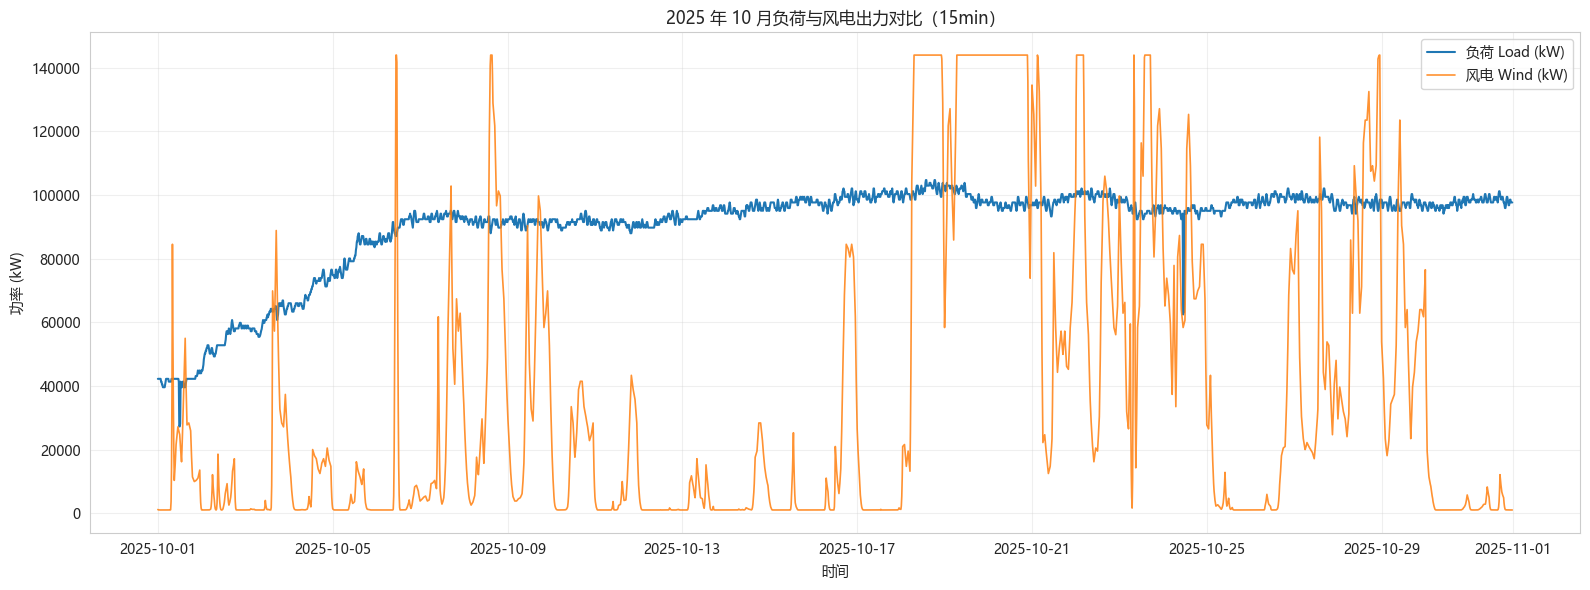

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

# ===============================
# 0. 中文字体（如不需要可删除）
# ===============================
font_path = r"C:\Windows\Fonts\msyh.ttc"
font_manager.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "Microsoft YaHei"
plt.rcParams["axes.unicode_minus"] = False

# ===============================
# 1. 确保 Time 是 DatetimeIndex
# ===============================
if not isinstance(df.index, pd.DatetimeIndex):
    df.index = pd.to_datetime(df.index)

# ===============================
# 2. 提取 2025 年 10 月数据
# ===============================
df_oct = df.loc["2025-10"]

print("10 月数据形状:", df_oct.shape)
print(df_oct.head())

# ===============================
# 3. 画图
# ===============================
plt.figure(figsize=(16, 6))

plt.plot(
    df_oct.index,
    df_oct["Load_kW"],
    label="负荷 Load (kW)",
    linewidth=1.5,
)

plt.plot(
    df_oct.index,
    df_oct["Wind_kW"],
    label="风电 Wind (kW)",
    linewidth=1.2,
    alpha=0.85,
)

plt.title("2025 年 10 月负荷与风电出力对比（15min）")
plt.xlabel("时间")
plt.ylabel("功率 (kW)")
plt.legend(loc="upper right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [76]:
df_2025_ = df_2025.copy()
df_2025_['P_kw'] = df_2025_['P_kw']*6.85/7.04
df, dt_h = align_and_merge(df_2025, df_wind)

In [74]:
print(df_2025)

                     Time     P_kw
0     2025-01-01 00:00:00  68640.0
1     2025-01-01 00:15:00  68640.0
2     2025-01-01 00:30:00  68640.0
3     2025-01-01 00:45:00  68640.0
4     2025-01-01 01:00:00  68640.0
...                   ...      ...
35035 2025-12-31 22:45:00  67760.0
35036 2025-12-31 23:00:00  68640.0
35037 2025-12-31 23:15:00  68640.0
35038 2025-12-31 23:30:00  68640.0
35039 2025-12-31 23:45:00  68640.0

[35040 rows x 2 columns]


In [71]:
import numpy as np
import matplotlib.pyplot as plt

# 用你现有的仿真函数：simulate_dispatch_offgrid_shiftable
# 如果你用的是我给你的那版代码，函数名就是 simulate_dispatch_offgrid_shiftable

def plot_capacity_curve(df, dt_h, bess, policy,
                       cap_max_mwh=None, n_points=30):
    load_kw = df["Load_kW"].to_numpy(float)
    wind_kw = df["Wind_kW"].to_numpy(float)

    # 上限默认用你求出来的容量的 1.3 倍
    if cap_max_mwh is None:
        cap_max_mwh = 1.3 * 1400  # 你这里大约 1377，可自行改

    # 取“对数更密集”的采样点，减少计算量但更能看陡峭区
    caps = np.unique(np.round(np.geomspace(1, cap_max_mwh, n_points), 1))
    caps = np.insert(caps, 0, 0.0)

    covs = []
    selfs = []
    for c in caps:
        r = simulate_dispatch_offgrid_shiftable(load_kw, wind_kw, dt_h, float(c), bess, policy)
        covs.append(r["metrics"]["load_coverage"])
        selfs.append(r["metrics"]["green_self_consumption"])

    plt.figure()
    plt.plot(caps, covs, marker="o", label="Load coverage")
    plt.plot(caps, selfs, marker="o", label="Green self-consumption")
    plt.axhline(0.30, linestyle="--")
    plt.axhline(0.60, linestyle="--")
    plt.xlabel("Capacity (MWh)")
    plt.ylabel("Ratio")
    plt.title("Capacity vs Coverage / Self-consumption")
    plt.legend()
    plt.grid(True)
    plt.show()

# 示例调用：
# plot_capacity_curve(df, dt_h, bess, policy, cap_max_mwh=2000, n_points=30)


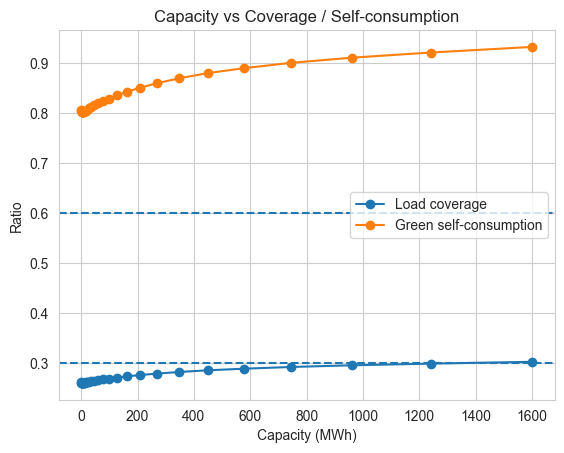

In [72]:

# 2. 固定电池与策略参数
bess = BESSConfig(
    eta_charge=0.92,
    eta_discharge=0.92,
    soc_min=0.10,
    soc_max=1.00,
    soc_init=0.50,
    c_rate=1.0,
    enforce_terminal_soc=False,
)

policy = ShiftPolicy(
    enable_shift=True,
    lookahead_steps=8,
    shift_max_frac_of_wind=0.30,
)

# 3. 画“容量响应曲线”
plot_capacity_curve(
    df=df,
    dt_h=dt_h,
    bess=bess,
    policy=policy,
    cap_max_mwh=1600,
    n_points=30,
)

In [91]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Union, Optional, Dict, Any


# ============================================================
# 1. 配置
# ============================================================

@dataclass
class BESSConfig:
    eta_charge: float = 0.92
    eta_discharge: float = 0.92
    soc_min: float = 0.10
    soc_max: float = 1.00
    soc_init: float = 0.50
    c_rate: float = 1.0


@dataclass
class Targets:
    min_wind_utilization: float = 0.60   # 风电消纳率
    min_load_coverage: float = 0.30      # 负荷覆盖率


# ============================================================
# 2. 数据读取 & 对齐
# ============================================================

def read_timeseries(obj: Union[str, pd.DataFrame]) -> pd.DataFrame:
    if isinstance(obj, pd.DataFrame):
        df = obj.copy()
    else:
        ext = os.path.splitext(obj.lower())[1]
        if ext == ".csv":
            df = pd.read_csv(obj)
        elif ext in [".xls", ".xlsx"]:
            df = pd.read_excel(obj)
        else:
            raise ValueError("Unsupported file type")

    if "Time" in df.columns:
        df["Time"] = pd.to_datetime(df["Time"])
        df = df.set_index("Time")
    elif isinstance(df.index, pd.DatetimeIndex):
        pass
    else:
        raise ValueError("Need Time column or DatetimeIndex")

    return df.sort_index()


def align_and_merge(
    df_load: pd.DataFrame,
    df_wind: pd.DataFrame,
    load_col_kw: str = "P_kw",
    wind_col_mw: str = "WindPower_MW",
    freq: Optional[str] = None,
):
    if freq is None:
        freq = pd.infer_freq(df_load.index) or "15min"

    idx = pd.date_range(
        max(df_load.index.min(), df_wind.index.min()),
        min(df_load.index.max(), df_wind.index.max()),
        freq=freq,
    )

    dfl = df_load[[load_col_kw]].rename(columns={load_col_kw: "Load_kW"}).reindex(idx).interpolate()
    dfw = df_wind[[wind_col_mw]].rename(columns={wind_col_mw: "Wind_MW"}).reindex(idx).interpolate()
    dfw["Wind_kW"] = dfw["Wind_MW"] * 1000
    dfw = dfw.drop(columns=["Wind_MW"])

    df = pd.concat([dfl, dfw], axis=1)
    dt_h = pd.to_timedelta(freq).total_seconds() / 3600
    return df, dt_h


# ============================================================
# 3. 弃电搬运调度（核心）
# ============================================================

def simulate_surplus_shift(
    load_kw, wind_kw, dt_h, cap_mwh, bess: BESSConfig
):
    cap_kwh = cap_mwh * 1000
    pmax = bess.c_rate * cap_kwh
    e = bess.soc_init * cap_kwh
    e_min = bess.soc_min * cap_kwh
    e_max = bess.soc_max * cap_kwh

    n = len(load_kw)
    soc = np.zeros(n)
    charge = np.zeros(n)
    discharge = np.zeros(n)
    served = np.zeros(n)
    curtail = np.zeros(n)

    for t in range(n):
        L = load_kw[t]
        W = wind_kw[t]

        served_direct = min(L, W)
        surplus = max(W - L, 0)
        deficit = max(L - W, 0)

        room = max(e_max - e, 0)
        avail = max(e - e_min, 0)

        ch = min(surplus, pmax, room / (bess.eta_charge * dt_h))
        dis = min(deficit, pmax, avail * bess.eta_discharge / dt_h)

        e += (ch * bess.eta_charge - dis / bess.eta_discharge) * dt_h
        e = np.clip(e, e_min, e_max)

        charge[t] = ch
        discharge[t] = dis
        served[t] = served_direct + dis
        curtail[t] = max(surplus - ch, 0)
        soc[t] = e / cap_kwh if cap_kwh > 0 else bess.soc_init

    E_load = load_kw.sum() * dt_h
    E_wind = wind_kw.sum() * dt_h
    E_served = served.sum() * dt_h

    return {
        "wind_util": E_served / E_wind if E_wind > 0 else 0,
        "load_cov": E_served / E_load if E_load > 0 else 0,
        "series": {
            "served": served,
            "charge": charge,
            "discharge": discharge,
            "curtail": curtail,
            "soc": soc,
        }
    }


# ============================================================
# 4. 最小容量搜索（二分）
# ============================================================

def find_min_capacity(
    load_kw, wind_kw, dt_h, bess, targets, cap_max=5000, tol=0.1
):
    # 可达性检查
    r_inf = simulate_surplus_shift(load_kw, wind_kw, dt_h, cap_mwh=1e6, bess=bess)
    if r_inf["wind_util"] < targets.min_wind_utilization or \
       r_inf["load_cov"] < targets.min_load_coverage:
        raise RuntimeError(
            f"目标在物理上不可达：\n"
            f"最大风电消纳率={r_inf['wind_util']:.3f}, "
            f"最大负荷覆盖率={r_inf['load_cov']:.3f}"
        )

    lo, hi = 0.0, 1.0
    while hi <= cap_max:
        r = simulate_surplus_shift(load_kw, wind_kw, dt_h, hi, bess)
        if r["wind_util"] >= targets.min_wind_utilization and \
           r["load_cov"] >= targets.min_load_coverage:
            break
        hi *= 2

    if hi > cap_max:
        raise RuntimeError("cap_max 不足")

    while hi - lo > tol:
        mid = (lo + hi) / 2
        r = simulate_surplus_shift(load_kw, wind_kw, dt_h, mid, bess)
        if r["wind_util"] >= targets.min_wind_utilization and \
           r["load_cov"] >= targets.min_load_coverage:
            hi = mid
        else:
            lo = mid

    return hi


# ============================================================
# 5. 主函数（你只调用这个）
# ============================================================

def run_wind_bess_planning_min_cap(
    load_file,
    wind_file,
    load_col_kw="P_kw",
    wind_col_mw="WindPower_MW",
    freq=None,
    cap_max_mwh=5000,
):

    bess = BESSConfig()
    targets = Targets()

    df_load = read_timeseries(load_file)
    df_wind = read_timeseries(wind_file)

    df, dt_h = align_and_merge(df_load, df_wind, load_col_kw, wind_col_mw, freq)

    load_kw = df["Load_kW"].values
    wind_kw = df["Wind_kW"].values

    cap = find_min_capacity(load_kw, wind_kw, dt_h, bess, targets, cap_max_mwh)

    res = simulate_surplus_shift(load_kw, wind_kw, dt_h, cap, bess)
    s = res["series"]

    schedule_df = pd.DataFrame({
        "Load_kW": load_kw,
        "Wind_kW": wind_kw,
        "Served_kW": s["served"],
        "Charge_kW": s["charge"],
        "Discharge_kW": s["discharge"],
        "Curtail_kW": s["curtail"],
        "SOC": s["soc"],
    }, index=df.index)

    return {
        "bess_capacity_mwh": cap,
        "wind_utilization": res["wind_util"],
        "load_coverage": res["load_cov"],
        "schedule_df": schedule_df,
    }


In [92]:
res = run_wind_bess_planning_min_cap(
    load_file=df_2025,
    wind_file=df_wind,
    cap_max_mwh=3000,
)

print("储能容量(MWh):", res["bess_capacity_mwh"])
print("风电消纳率:", res["wind_utilization"])
print("负荷覆盖率:", res["load_coverage"])

res["schedule_df"].head()


储能容量(MWh): 1085.0625
风电消纳率: 0.9253092699558629
负荷覆盖率: 0.3000000471381572


,Load_kW,Wind_kW,Served_kW,Charge_kW,Discharge_kW,Curtail_kW,SOC
2025-01-01 00:00:00,68640.0,87301.858030,68640.0,18661.85803,0.000000,0.0,0.503956
2025-01-01 00:15:00,68640.0,63441.819117,68640.0,0.00000,5198.180883,0.0,0.502654
2025-01-01 00:30:00,68640.0,44291.139028,68640.0,0.00000,24348.860972,0.0,0.496556
2025-01-01 00:45:00,68640.0,29297.268199,68640.0,0.00000,39342.731801,0.0,0.486703
2025-01-01 01:00:00,68640.0,18574.077308,68640.0,0.00000,50065.922692,0.0,0.474165


In [ ]:
print(df_2025.dtypes)
print(df_wind.dtypes)